In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')


✅ Libraries loaded successfully!


In [2]:
stock_sector_map = {
    'AAPL': 'US Technology', 'NVDA': 'US Technology', 'META': 'US Technology',
    'AVGO': 'US Technology', 'GOOGL': 'US Technology',
    'JNJ': 'US Healthcare', 'ABBV': 'US Healthcare', 'LLY': 'US Healthcare',
    'JPM': 'US Financial', 'GS': 'US Financial', 'V': 'US Financial',
    'XOM': 'US Energy', 'MPC': 'US Energy',
    'CAT': 'US Consumer', 'WMT': 'US Consumer', 'COST': 'US Consumer', 'MCD': 'US Consumer',
    'DELTA.BK': 'Thai Stocks', 'ADVANC.BK': 'Thai Stocks', 'KBANK.BK': 'Thai Stocks',
    'PDD': 'Chinese Stocks', 'FUTU': 'Chinese Stocks',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
}
portfolio_tickers = list(stock_sector_map.keys())
print(f'หุ้นเดิมในพอร์ต: {len(portfolio_tickers)} ตัว')
print(f'กลุ่ม: {len(set(stock_sector_map.values()))} กลุ่ม')


หุ้นเดิมในพอร์ต: 30 ตัว
กลุ่ม: 10 กลุ่ม


In [3]:
# === 3.1 S&P 500 — ดึงจาก Wikipedia ด้วย pd.read_html (robust กว่า BeautifulSoup) ===
print("📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...")
try:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    resp = requests.get(url, headers=headers, timeout=30)
    from io import StringIO
    tables = pd.read_html(StringIO(resp.text))
    df_sp500 = tables[0]  # ตารางแรกคือ constituents

    # หา column ชื่อ Symbol/Ticker และ GICS Sector
    sym_col = [c for c in df_sp500.columns if 'Symbol' in str(c) or 'Ticker' in str(c)][0]
    sec_col = [c for c in df_sp500.columns if 'GICS Sector' in str(c)][0]

    sp500_tickers = df_sp500[sym_col].str.replace('.', '-', regex=False).tolist()
    sp500_sector_map = dict(zip(
        df_sp500[sym_col].str.replace('.', '-', regex=False),
        df_sp500[sec_col]
    ))

    print(f"  ✅ ได้ {len(sp500_tickers)} ตัว")
except Exception as e:
    print(f"  ❌ ไม่สามารถดึงข้อมูล S&P 500 ได้: {e}")
    sp500_tickers = []
    sp500_sector_map = {}

# === 3.2 SET (Thai Stocks) ===
print("\n📥 รายชื่อหุ้นไทย (SET)...")
thai_tickers_raw = [
    'ADVANC', 'AOT', 'AWC', 'BANPU', 'BBL', 'BDMS', 'BEM', 'BGRIM',
    'BH', 'BTS', 'CBG', 'CENTEL', 'COM7', 'CPALL', 'CPF', 'CPN',
    'CRC', 'DELTA', 'EA', 'EGCO', 'GLOBAL', 'GPSC', 'GULF', 'HMPRO',
    'IVL', 'JMART', 'JMT', 'KBANK', 'KCE', 'KTB', 'KTC',
    'LH', 'MINT', 'MTC', 'OR', 'OSP', 'PTT', 'PTTEP', 'PTTGC',
    'RATCH', 'SAWAD', 'SCB', 'SCC', 'SCGP', 'TISCO', 'TOP',
    'TRUE', 'TTB', 'TU', 'WHA',
    'BEAUTY', 'BCH', 'BCP', 'BJC', 'BLA',
    'GFPT', 'IRPC', 'ITD', 'MAJOR', 'MEGA', 'PLANB',
    'PSL', 'RS', 'SPALI', 'SYNEX',
    'TCAP', 'THANI', 'TPIPP', 'VGI',
]
thai_tickers = [t + '.BK' for t in thai_tickers_raw]
thai_sector_map = {t + '.BK': 'Thai Stocks' for t in thai_tickers_raw}
print(f"  ✅ ได้ {len(thai_tickers)} ตัว")

# === 3.3 Chinese ADRs ===
print("\n📥 รายชื่อหุ้นจีน (ADRs)...")
chinese_tickers = [
    'BABA', 'JD', 'PDD', 'BIDU', 'NIO', 'XPEV', 'LI', 'FUTU',
    'TME', 'BILI', 'IQ', 'ZTO', 'MNSO', 'VNET', 'DIDI',
    'TAL', 'EDU', 'NTES', 'WB', 'HTHT',
]
chinese_sector_map = {t: 'Chinese Stocks' for t in chinese_tickers}
print(f"  ✅ ได้ {len(chinese_tickers)} ตัว")

# === 3.4 ETFs ===
print("\n📥 รายชื่อ ETFs...")
etf_tickers = [
    'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'VCSH', 'EMLC', 'BND', 'AGG',
    'TIPS', 'MUB', 'BNDX',
    'GLD', 'SLV', 'COPX', 'USO', 'UNG', 'DBA', 'PDBC', 'GSG',
    'PPLT', 'PALL', 'CPER',
    'BTC-USD', 'ETH-USD',
    'EEM', 'VWO', 'EFA', 'VEA', 'MCHI', 'FXI', 'THD',
    'QQQ', 'SPY', 'IWM', 'VTI', 'DIA',
]
etf_sector_map = {
    'TLT': 'Bonds', 'IEF': 'Bonds', 'SHY': 'Bonds', 'LQD': 'Bonds',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds', 'BND': 'Bonds',
    'AGG': 'Bonds', 'TIPS': 'Bonds', 'MUB': 'Bonds', 'BNDX': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
    'USO': 'Commodities', 'UNG': 'Commodities', 'DBA': 'Commodities',
    'PDBC': 'Commodities', 'GSG': 'Commodities', 'PPLT': 'Commodities',
    'PALL': 'Commodities', 'CPER': 'Commodities',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'EEM': 'EM ETF', 'VWO': 'EM ETF', 'EFA': 'Intl ETF', 'VEA': 'Intl ETF',
    'MCHI': 'China ETF', 'FXI': 'China ETF', 'THD': 'Thai ETF',
    'QQQ': 'US ETF', 'SPY': 'US ETF', 'IWM': 'US ETF', 'VTI': 'US ETF', 'DIA': 'US ETF',
}
print(f"  ✅ ได้ {len(etf_tickers)} ตัว")

# === รวมทั้งหมด ===
all_tickers = list(set(sp500_tickers + thai_tickers + chinese_tickers + etf_tickers + portfolio_tickers))
all_tickers.sort()

all_sector_map = {}
all_sector_map.update(sp500_sector_map)
all_sector_map.update(thai_sector_map)
all_sector_map.update(chinese_sector_map)
all_sector_map.update(etf_sector_map)

print(f"\n🎯 รวมทั้งหมด: {len(all_tickers)} ตัว (หลังลบ duplicates)")


📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...
  ✅ ได้ 503 ตัว

📥 รายชื่อหุ้นไทย (SET)...
  ✅ ได้ 69 ตัว

📥 รายชื่อหุ้นจีน (ADRs)...
  ✅ ได้ 20 ตัว

📥 รายชื่อ ETFs...
  ✅ ได้ 37 ตัว

🎯 รวมทั้งหมด: 629 ตัว (หลังลบ duplicates)


In [5]:
import os
import time
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# สมมติว่ามีตัวแปร all_tickers ถูกประกาศไว้แล้วก่อนหน้านี้
# all_tickers = [...]

start_date='2015-01-01' 
end_date='2025-01-01'

print(f"ช่วงเวลา: {start_date} ถึง {end_date}")
print("⏳ กรุณารอสักครู่...\n")

batch_size = 100
all_data_list = []
tickers_to_download = []
all_data = pd.DataFrame()

# 1. ตรวจสอบไฟล์และหา Tickers ที่ต้องดาวน์โหลด
if os.path.exists('all_data_10_year.csv'):
    print("📂 พบไฟล์ all_data.csv อยู่แล้ว, กำลังโหลด...")
    all_data = pd.read_csv('all_data.csv', index_col=0, parse_dates=True)
    existing_tickers = set(all_data.columns)
    tickers_to_download = [t for t in all_tickers if t not in existing_tickers]
    
    if tickers_to_download:
        print(f"⚠️ พบ {len(tickers_to_download)} ตัวที่ยังไม่มีข้อมูลในไฟล์:")
        print(", ".join(tickers_to_download))
        print("⏳ กำลังดาวน์โหลดข้อมูลที่ขาดหาย...")
    else:
        print("✅ ข้อมูลครบถ้วนแล้ว ไม่มีตัวไหนขาดหาย")
else:        
    tickers_to_download = all_tickers
    print(f"กำลังดาวน์โหลดข้อมูลใหม่ทั้งหมด {len(tickers_to_download)} ตัว...")

# 2. วนลูปดาวน์โหลดเฉพาะ Tickers ที่ต้องการ
if tickers_to_download:
    for i in range(0, len(tickers_to_download), batch_size):
        batch = tickers_to_download[i:i+batch_size]
        batch_num = i // batch_size + 1
        total_batches = (len(tickers_to_download) + batch_size - 1) // batch_size
        print(f"  Batch {batch_num}/{total_batches}: downloading {len(batch)} tickers...", end=" ")
        
        try:
            batch_data = yf.download(batch, start=start_date, end=end_date, auto_adjust=True, threads=True)
            # Handle MultiIndex columns from yf.download
            if isinstance(batch_data.columns, pd.MultiIndex):
                batch_close = batch_data['Close']
            else:
                # Single ticker case
                batch_close = batch_data[['Close']].rename(columns={'Close': batch[0]})
            
            all_data_list.append(batch_close)
            n_cols = batch_close.shape[1] if isinstance(batch_close, pd.DataFrame) else 1
            print(f"✅ ได้ {n_cols} ตัว")
        except Exception as e:
            print(f"❌ Error: {e}")
        
        time.sleep(1)

# 3. นำข้อมูลใหม่มารวมกับข้อมูลเดิม (ตรวจสอบก่อน concat)
if all_data_list:
    new_data = pd.concat(all_data_list, axis=1)
    
    # ถ้ารวมกับไฟล์เดิมที่มีอยู่
    if not all_data.empty:
        all_data = pd.concat([all_data, new_data], axis=1)
    else:
        all_data = new_data
        
    all_data = all_data.loc[:, ~all_data.columns.duplicated()]
    all_data.to_csv('all_data.csv')
    print("💾 อัปเดตและบันทึกไฟล์ all_data.csv เรียบร้อยแล้ว")

print(f"\n📊 สรุปจำนวนข้อมูลทั้งหมด: {all_data.shape[1]} ตัว, {all_data.shape[0]} วัน")

ช่วงเวลา: 2015-01-01 ถึง 2025-01-01
⏳ กรุณารอสักครู่...

กำลังดาวน์โหลดข้อมูลใหม่ทั้งหมด 629 ตัว...
  Batch 1/7: downloading 100 tickers... 

[*********************100%***********************]  100 of 100 completed


✅ ได้ 100 ตัว


[                       0%                       ]

  Batch 2/7: downloading 100 tickers... 

...

  Batch 6/7: downloading 100 tickers... 

[***************       31%                       ]  31 of 100 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[*********************100%***********************]  100 of 100 completed

1 Failed download:
['SNDK']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")


✅ ได้ 100 ตัว
  Batch 7/7: downloading 29 tickers... 

[*********************100%***********************]  29 of 29 completed


✅ ได้ 29 ตัว
💾 อัปเดตและบันทึกไฟล์ all_data.csv เรียบร้อยแล้ว

📊 สรุปจำนวนข้อมูลทั้งหมด: 629 ตัว, 3653 วัน


In [79]:
all_data_list

[Ticker               A        AAPL        ABBV        ABNB         ABT  \
 Date                                                                     
 2010-01-04   19.810982    6.412383         NaN         NaN   18.321970   
 2010-01-05   19.595785    6.423468         NaN         NaN   18.173943   
 2010-01-06   19.526157    6.321296         NaN         NaN   18.274878   
 2010-01-07   19.500843    6.309611         NaN         NaN   18.426270   
 2010-01-08   19.494514    6.351559         NaN         NaN   18.520470   
 ...                ...         ...         ...         ...         ...   
 2026-04-01  114.540001  255.630005  214.979996  125.190002  102.379997   
 2026-04-02  115.480003  255.919998  208.839996  124.949997  102.870003   
 2026-04-03         NaN         NaN         NaN         NaN         NaN   
 2026-04-06  114.839996  258.859985  206.690002  126.809998  102.300003   
 2026-04-07  113.629997  249.149094  203.789993  125.114998  102.559998   
 
 Ticker           ACGL 

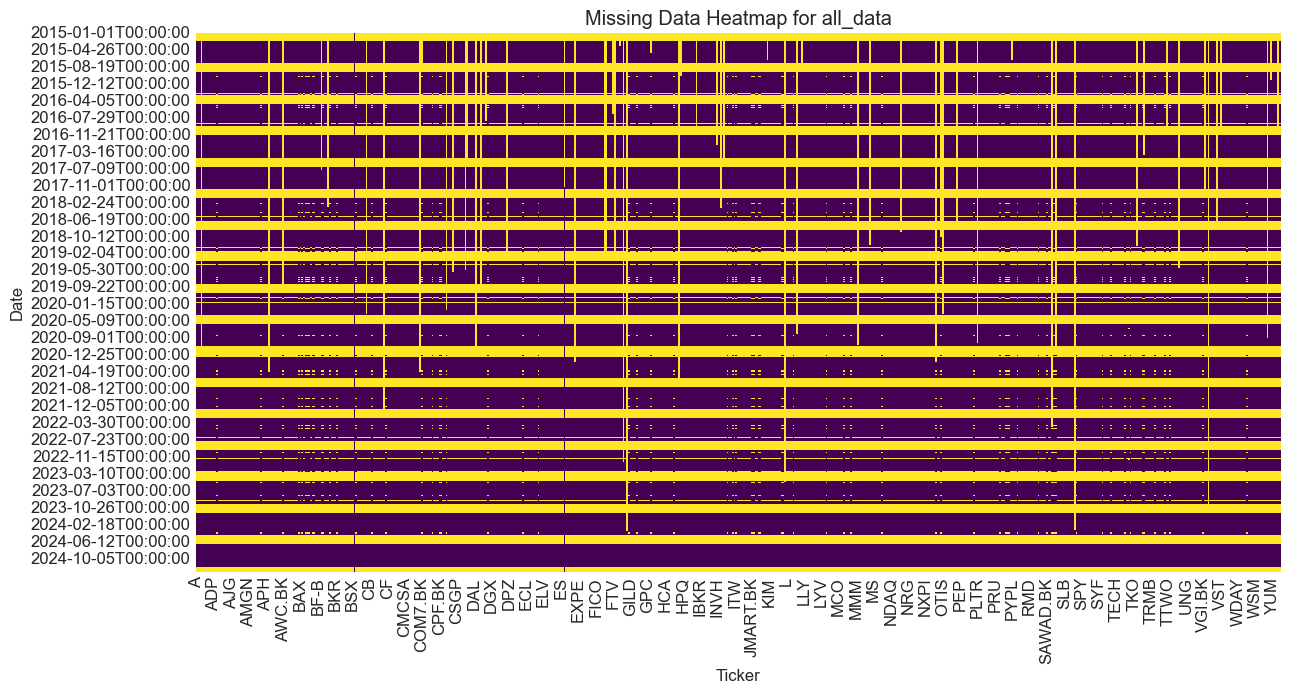

In [6]:
plt.figure(figsize=(14, 7))
sns.heatmap(all_data.dropna(axis=1, how='all').isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap for all_data')
plt.show()

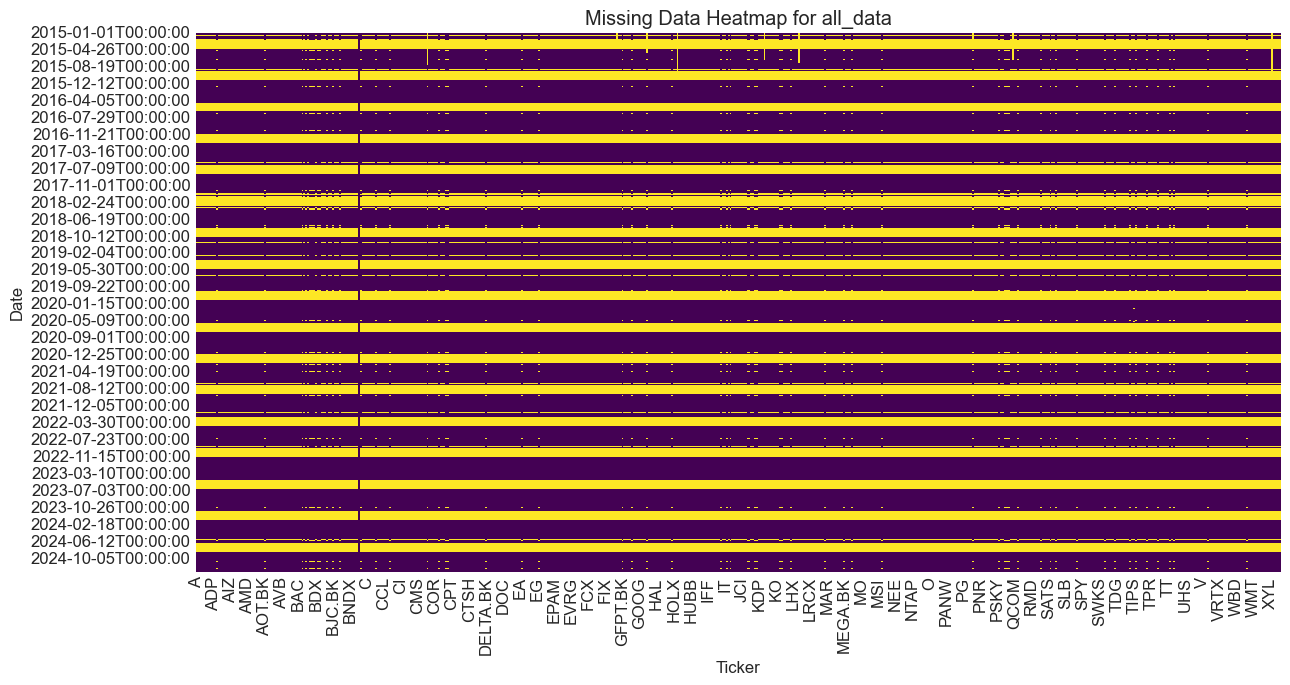

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,36.970352,24.214893,41.755470,36.235115,18.539352,74.252602,72.339996,44.216053,37.381660,65.025330,...,23.302099,125.731461,25.351812,57.533440,33.037388,NaN,42.024681,99.672615,77.430000,39.581657
2015-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,36.277618,23.532721,40.969673,36.243195,18.428413,72.998901,71.980003,43.411961,36.088184,64.978500,...,23.302099,123.591537,25.064039,55.959194,30.981220,NaN,41.170830,103.390770,76.339996,39.344048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,133.904007,254.201370,170.623245,112.282875,92.339996,351.166351,446.480011,212.803284,48.316326,287.383148,...,26.857538,87.634689,64.964241,102.030319,115.749687,88.970001,132.053116,105.301056,389.070007,161.750626
2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Define the maximum allowed consecutive gap (e.g., 30 trading days)
max_gap = 365

# Find columns that have a gap of NaNs larger than max_gap
mask = all_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()

# Filter them out
data = all_data.loc[:, ~cols_with_long_strips].copy()
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap for all_data')
plt.show()
data

In [8]:
# Get the names of the columns where the condition was True
dropped_cols = cols_with_long_strips[cols_with_long_strips].index.tolist()

print(f"Dropped {len(dropped_cols)} columns:")
print(dropped_cols)

Dropped 56 columns:
['ABNB', 'APP', 'AWC.BK', 'BGRIM.BK', 'BILI', 'CARR', 'CEG', 'COIN', 'CRC.BK', 'CRWD', 'CTVA', 'CVNA', 'DASH', 'DDOG', 'DELL', 'DIDI', 'DOW', 'ETH-USD', 'EXE', 'FOX', 'FOXA', 'FTV', 'FUTU', 'GEHC', 'GEV', 'GULF.BK', 'HOOD', 'HWM', 'INVH', 'IQ', 'IR', 'KVUE', 'LI', 'MNSO', 'MRNA', 'NIO', 'OR.BK', 'OSP.BK', 'OTIS', 'PDD', 'PLTR', 'Q', 'SCB.BK', 'SCGP.BK', 'SNDK', 'SOLV', 'TME', 'TPIPP.BK', 'TTD', 'UBER', 'VICI', 'VLTO', 'VRT', 'VST', 'XPEV', 'ZTO']


In [9]:
# Currency Conversion: All Prices to THB
data_filtered = data.copy()
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

data_thb = data_filtered.copy()
thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb


[*********************100%***********************]  1 of 1 completed

  USD/THB range: 29.68 - 38.30

Converted 513 USD assets to THB
Thai assets (60): already in THB


array([[2.34000000e+02, 2.35000000e+02, 1.18373930e-01, 2.00000000e+00],
       [3.84000000e+02, 3.85000000e+02, 1.44618571e-01, 2.00000000e+00],
       [2.20000000e+02, 3.36000000e+02, 1.50022209e-01, 2.00000000e+00],
       ...,
       [1.14000000e+03, 1.14100000e+03, 3.62012304e+00, 4.30000000e+02],
       [1.13700000e+03, 1.14200000e+03, 4.11549043e+00, 4.81000000e+02],
       [1.13900000e+03, 1.14300000e+03, 4.56563459e+00, 5.73000000e+02]],
      shape=(572, 4))

In [75]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import math
# 1. กำหนด Device ให้อยู่บน GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



# data = all_data.dropna(axis=1, how='all').copy()
# --- จัดการ Missing Data ---
# ตัดหุ้นที่มีข้อมูลหายไปมากกว่า 10% ออก (รับรองว่ามีข้อมูลอย่างน้อย 90%)
# Define the maximum allowed consecutive gap (e.g., 30 trading days)
# max_gap = 365

# # Find columns that have a gap of NaNs larger than max_gap
# mask = all_data.isnull().rolling(window=max_gap).sum()
# cols_with_long_strips = (mask == max_gap).any()

# # Filter them out
# data = all_data.loc[:, ~cols_with_long_strips].copy()

# เติมข้อมูลในวันที่หายไปด้วยราคาของวันก่อนหน้า (Forward Fill) และวันถัดไป (Backward Fill)
data = data.ffill().bfill()

valid_tickers = data.columns

# 3. แปลงข้อมูลราคาเป็น PyTorch Tensor และย้ายไปรันบน GPU
# 3. แปลงข้อมูลราคาเป็น PyTorch Tensor และย้ายไปรันบน GPU
prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape

# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    X_centered = X - torch.mean(X, dim=0)
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    delta = 0.2 
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov


def ledoit_wolf_covariance_gpu_dynamic(X):
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    # ทฤษฎี LW ดั้งเดิมมักใช้ n_samples แทน n_samples-1 เพื่อความสะดวกในสูตรคณิตศาสตร์
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # ---------------------------------------------------------
    # ส่วนที่เพิ่มเข้ามา: คำนวณ Dynamic Delta (Optimal Shrinkage)
    # ---------------------------------------------------------
    
    # คำนวณ Squared Distance ระหว่าง Sample Covariance และ Target (d^2)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    
    # คำนวณ Variance ของสมาชิกใน Sample Covariance (b^2)
    # ใช้การคูณแบบ Element-wise ของข้อมูลที่ Center แล้ว
    X_squared = X_centered ** 2
    # ค่าประมาณความแปรปรวนแบบ Asymptotic
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    # คำนวณค่า Optimal Delta แบบ Dynamic
    # ป้องกันกรณีที่ b_squared มากกว่า d_squared หรือค่า delta หลุดกรอบ [0, 1]
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # ---------------------------------------------------------
    
    # 4. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()

shrunk_cov_gpu, sample_cov_gpu, delta_value = ledoit_wolf_covariance_gpu_dynamic(returns_gpu)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)

# 6. คำนวณ Distance Matrix บน GPU ตามสมการอ้างอิง: D = sqrt(0.5 * (1 - rho))
distance_matrix_gpu =  torch.arccos(corr_matrix_gpu) / math.pi  # ใช้ arccos เพื่อแปลง Correlation เป็น Distance แบบ Angular

# บังคับให้ระยะทางของหุ้นตัวเดียวกัน (เส้นทแยงมุม) เป็น 0 เสมอ
distance_matrix_gpu.fill_diagonal_(0.0)

# 7. ย้ายข้อมูลกลับมาที่ CPU สำหรับ Hierarchical Clustering
distance_matrix_cpu = distance_matrix_gpu.cpu().numpy()

# แปลง Distance matrix เป็น Condensed format สำหรับ scipy linkage
condensed_dist = squareform(distance_matrix_cpu, checks=False)

# 8. ทำ Hierarchical Clustering (ใช้ 'ward' linkage ได้ตามความเหมาะสมของ Distance metric นี้)
Z = linkage(condensed_dist, method='ward')

# 9. แบ่งกลุ่มออกเป็น 10 Clusters
num_clusters = min(30, len(valid_tickers))
cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')

# 10. เลือกหุ้น 1 ตัวแทนจากแต่ละ Cluster ที่มีความเสี่ยง (Variance) ต่ำสุด
# ---------------------------------------------------------
# 10. เลือกหุ้น 1 ตัวแทนจากแต่ละ Cluster ด้วย Annualised Sharpe Ratio สูงสุด
# ---------------------------------------------------------

# คำนวณ Mean Return รายวันบน GPU
mean_returns_gpu = torch.mean(returns_gpu, dim=0)

# ดึงค่า Volatility รายวัน (Standard Deviation) จากแนวทแยงมุมของ Shrunk Covariance
vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))

# คำนวณ Annualised Sharpe Ratio บน GPU
sharpe_ratios_gpu = math.sqrt(252) * (mean_returns_gpu / vols_gpu)

# ย้ายข้อมูล Sharpe Ratio กลับมาที่ CPU เพื่อใช้คัดกรองกับ Cluster Labels
sharpe_ratios_cpu = sharpe_ratios_gpu.cpu().numpy()

selected_stocks = []

for i in range(1, num_clusters + 1):
    cluster_indices = (cluster_labels == i).nonzero()[0]
    
    # หา index ของหุ้นในกลุ่มนี้ที่มี Sharpe Ratio สูงที่สุด (argmax)
    max_sharpe_idx = cluster_indices[sharpe_ratios_cpu[cluster_indices].argmax()]
    
    ticker_name = valid_tickers[max_sharpe_idx]
    selected_stocks.append(ticker_name)

print("\n=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนที่มี Annualised Sharpe Ratio สูงสุดจากแต่ละกลุ่ม) ===")
for idx, stock in enumerate(selected_stocks, 1):
    print(f"{idx}. {stock}")

Using device: cuda

=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนที่มี Annualised Sharpe Ratio สูงสุดจากแต่ละกลุ่ม) ===
1. BCP.BK
2. COM7.BK
3. TISCO.BK
4. AOT.BK
5. ATO
6. EQIX
7. IRM
8. VCSH
9. ISRG
10. LLY
11. UNH
12. WRB
13. PGR
14. CHD
15. COST
16. TMUS
17. NTES
18. NVDA
19. CDNS
20. FICO
21. TPL
22. GLD
23. BTC-USD
24. PDBC
25. STLD
26. ORLY
27. ARES
28. FIX
29. IBKR
30. HLT


In [76]:
distance_matrix_cpu.shape

(573, 573)

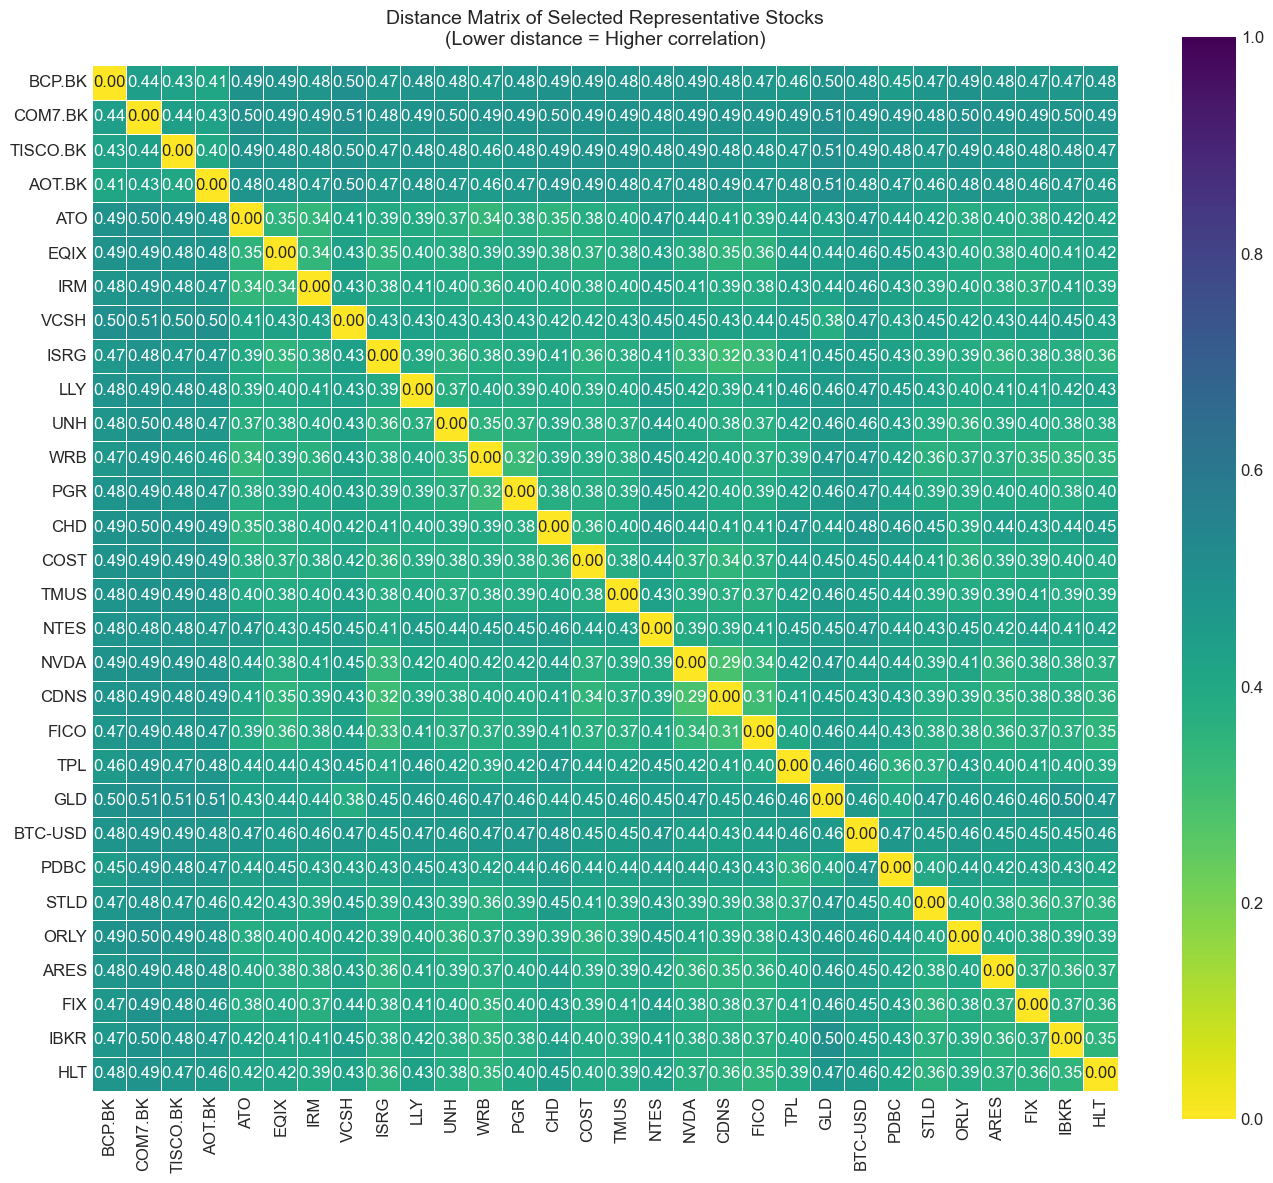

In [77]:
# --- แก้ไขส่วนการเลือกหุ้นเพื่อให้เก็บ Index ไว้ใช้งานต่อ ---
selected_stocks = []
selected_indices = []

for i in range(1, num_clusters + 1):
    cluster_indices = (cluster_labels == i).nonzero()[0]
    
    # หา index ของหุ้นที่มี Sharpe Ratio สูงที่สุดในกลุ่ม
    max_sharpe_idx = cluster_indices[sharpe_ratios_cpu[cluster_indices].argmax()]
    
    selected_indices.append(max_sharpe_idx)
    selected_stocks.append(valid_tickers[max_sharpe_idx])

# --- ส่วนการพลอต Distance Matrix ของหุ้นที่ถูกคัดเลือก ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Subset Matrix ให้เหลือเฉพาะหุ้นที่เลือก (Selected Indices)
selected_dist_matrix = distance_matrix_cpu[selected_indices][:, selected_indices]

plt.figure(figsize=(14, 12))

# 2. สร้าง Heatmap
sns.heatmap(
    selected_dist_matrix, 
    annot=True, # แสดงตัวเลขในช่อง
    cmap='viridis_r', # ใช้ viridis_r (0=เข้ม/ใกล้, 1=สว่าง/ไกล) จะดูง่ายกว่าสำหรับ Distance
    vmin=0.0, # ระยะทางต่ำสุดคือ 0 (เหมือนกันเป๊ะ)
    vmax=1.0,# ระยะทางสูงสุดคือ 1 (ตรงข้ามกันเป๊ะ)
    fmt=".2f",
    linewidths=0.5, 
    square=True,
    xticklabels=selected_stocks, # ใส่ชื่อหุ้นที่แกน X
    yticklabels=selected_stocks # ใส่ชื่อหุ้นที่แกน Y
)

plt.title('Distance Matrix of Selected Representative Stocks\n(Lower distance = Higher correlation)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

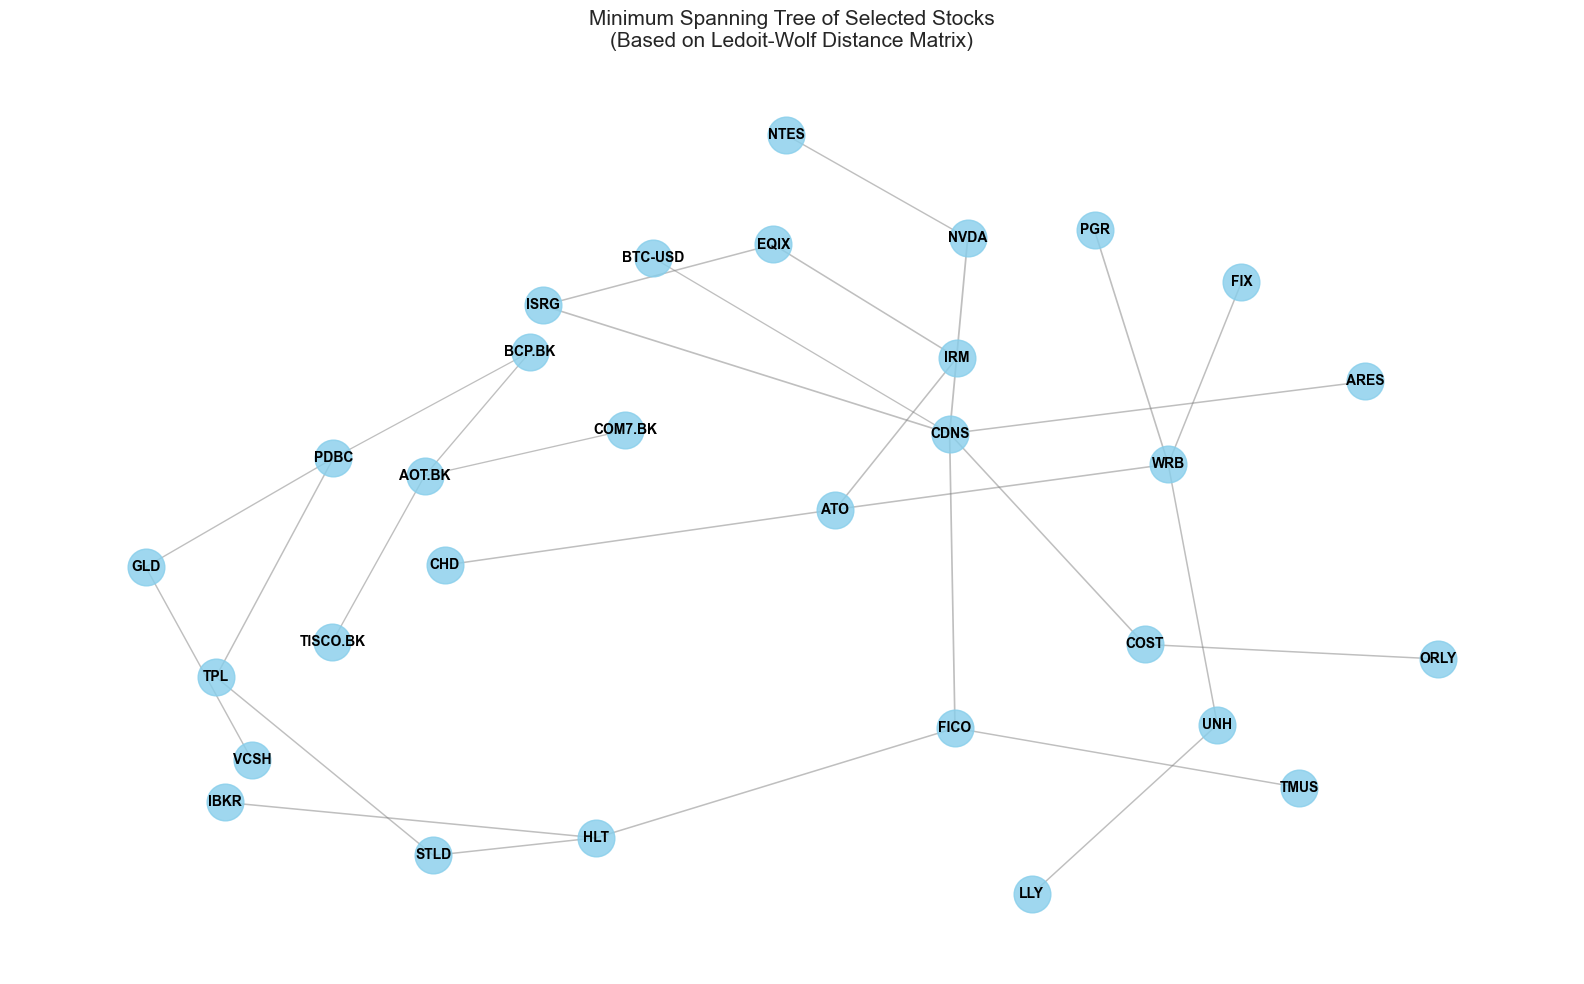

In [78]:
import networkx as nx

# 1. สร้าง Graph จาก Distance Matrix ของหุ้นที่เลือก
# เราจะสร้างเป็น Complete Graph ก่อน แล้วค่อยหา MST
G = nx.Graph()

# เพิ่ม Nodes (ชื่อหุ้น)
for stock in selected_stocks:
    G.add_node(stock)

# เพิ่ม Edges พร้อมน้ำหนัก (Distance)
n = len(selected_stocks)
for i in range(n):
    for j in range(i + 1, n):
        # selected_dist_matrix มาจากขั้นตอนที่แล้ว
        dist = selected_dist_matrix[i, j]
        G.add_edge(selected_stocks[i], selected_stocks[j], weight=dist)

# 2. คำนวณ Minimum Spanning Tree โดยใช้ Kruskal's หรือ Prim's algorithm
mst = nx.minimum_spanning_tree(G)

# 3. กำหนดการวางตำแหน่ง (Layout) สำหรับวาดรูป
# spring_layout จะพยายามดึงตัวที่ใกล้กัน (Distance ต่ำ) ให้อยู่ใกล้กันในภาพ
pos = nx.spring_layout(mst, seed=42, k=0.5) 

plt.figure(figsize=(16, 10))

# 4. วาด Nodes
nx.draw_networkx_nodes(mst, pos, node_size=700, node_color='skyblue', alpha=0.8)

# 5. วาด Edges (ยิ่งระยะทางสั้น เส้นยิ่งหนา เพื่อแสดงความสัมพันธ์ที่แน่นแฟ้น)
weights = [mst[u][v]['weight'] for u, v in mst.edges()]
# ปรับสเกลเส้น: 1/dist จะทำให้ตัวที่ใกล้กันเส้นหนาขึ้น
edge_widths = [1.0 / (w + 0.1) * 0.5 for w in weights] 

nx.draw_networkx_edges(mst, pos, width=edge_widths, edge_color='gray', alpha=0.5)

# 6. วาด Labels (ชื่อหุ้น)
nx.draw_networkx_labels(mst, pos, font_size=10, font_family='sans-serif', font_weight='bold')

plt.title('Minimum Spanning Tree of Selected Stocks\n(Based on Ledoit-Wolf Distance Matrix)', fontsize=15)
plt.axis('off') # ปิดแกน
plt.tight_layout()
plt.show()

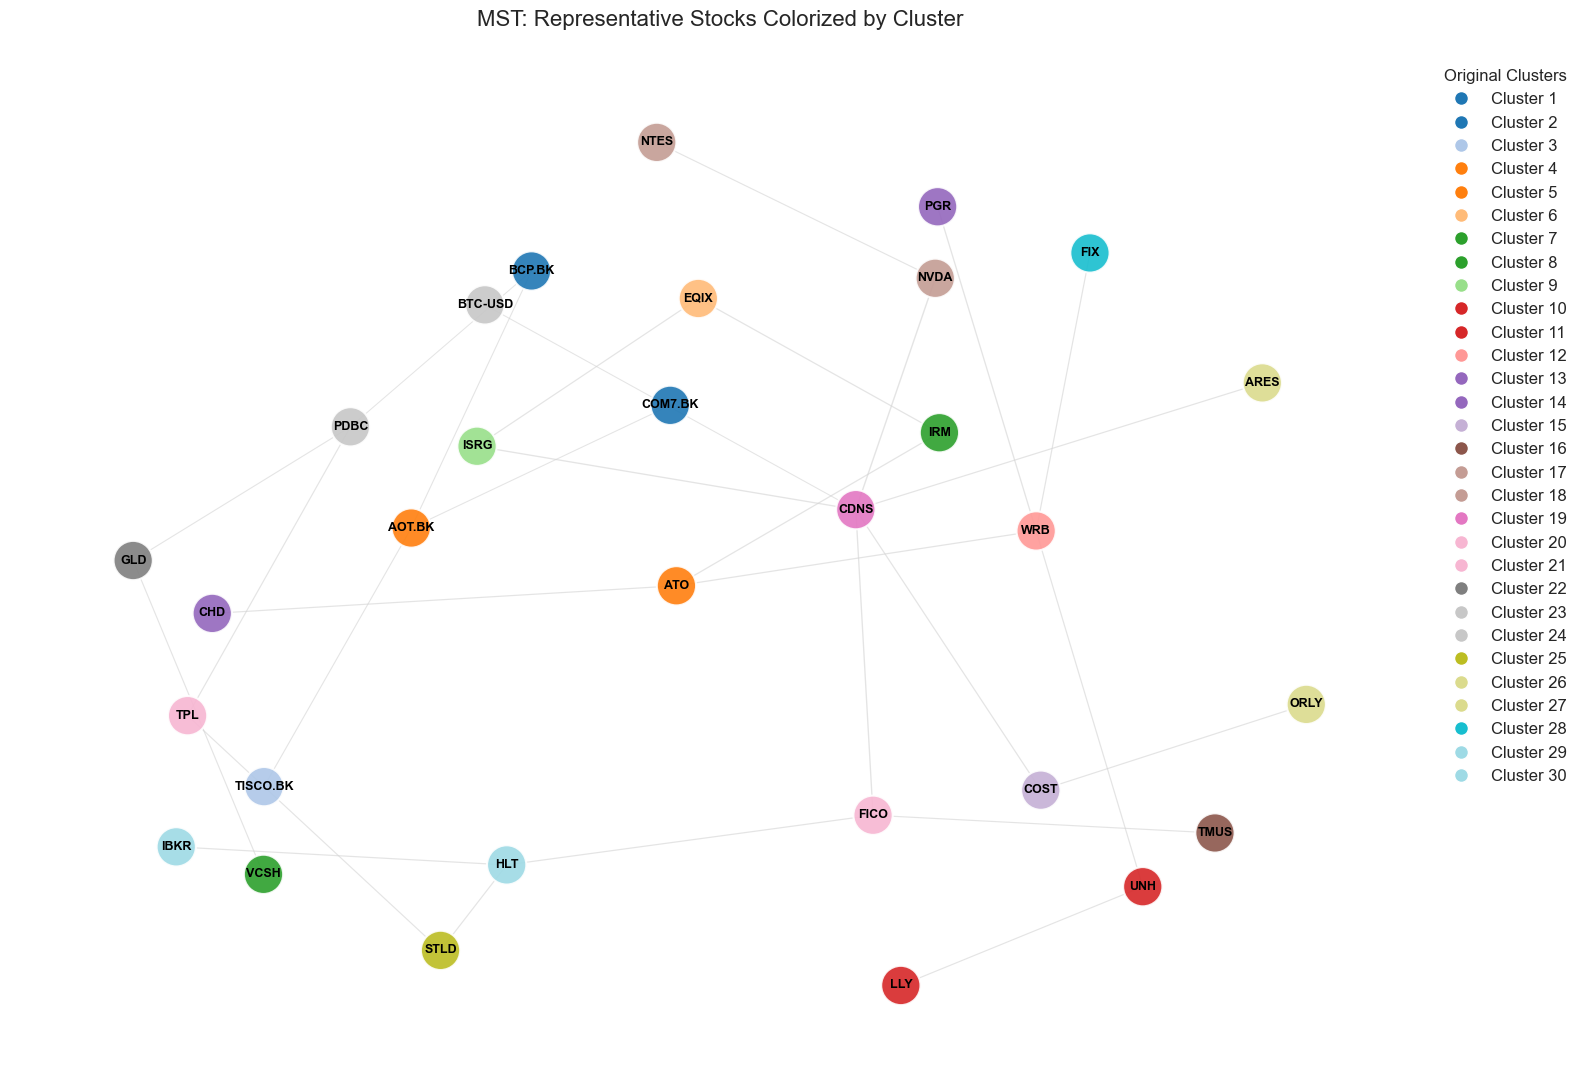

In [79]:
import matplotlib.cm as cm
import numpy as np

# 1. เตรียมค่าสีตาม Cluster ของหุ้นที่เลือก
# ดึง Cluster Label ของหุ้นที่เป็นตัวแทนออกมา
selected_cluster_ids = cluster_labels[selected_indices]

# สร้าง Colormap ตามจำนวน Cluster
unique_clusters = np.unique(selected_cluster_ids)
colors = cm.get_cmap('tab20', len(unique_clusters)) # ใช้ tab20 เพื่อสีที่หลากหลาย
cluster_color_map = {cluster_id: colors(i) for i, cluster_id in enumerate(unique_clusters)}
node_colors = [cluster_color_map[cluster_id] for cluster_id in selected_cluster_ids]

# 2. ตั้งค่า Layout
pos = nx.spring_layout(mst, seed=42, k=0.6) 

plt.figure(figsize=(16, 11))

# 3. วาด Edges (ความหนาตามความสัมพันธ์)
weights = [mst[u][v]['weight'] for u, v in mst.edges()]
edge_widths = [1.0 / (w + 0.1) * 0.4 for w in weights]
nx.draw_networkx_edges(mst, pos, width=edge_widths, edge_color='lightgray', alpha=0.6)

# 4. วาด Nodes โดยใส่สีตาม Cluster
nodes = nx.draw_networkx_nodes(
    mst, pos, 
    node_size=800, 
    node_color=node_colors, # ใส่ลิสต์ของสีที่เตรียมไว้
    alpha=0.9,
    edgecolors='white', # เพิ่มขอบสีขาวให้ดูสะอาดตา
    linewidths=1.5
)

# 5. วาด Labels
nx.draw_networkx_labels(mst, pos, font_size=9, font_weight='bold')

# 6. เพิ่ม Legend (คำอธิบายสี) เพื่อให้รู้ว่าสีไหนคือ Cluster อะไร
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Cluster {c_id}',
           markerfacecolor=cluster_color_map[c_id], markersize=10)
    for c_id in unique_clusters
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), title="Original Clusters")

plt.title('MST: Representative Stocks Colorized by Cluster', fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

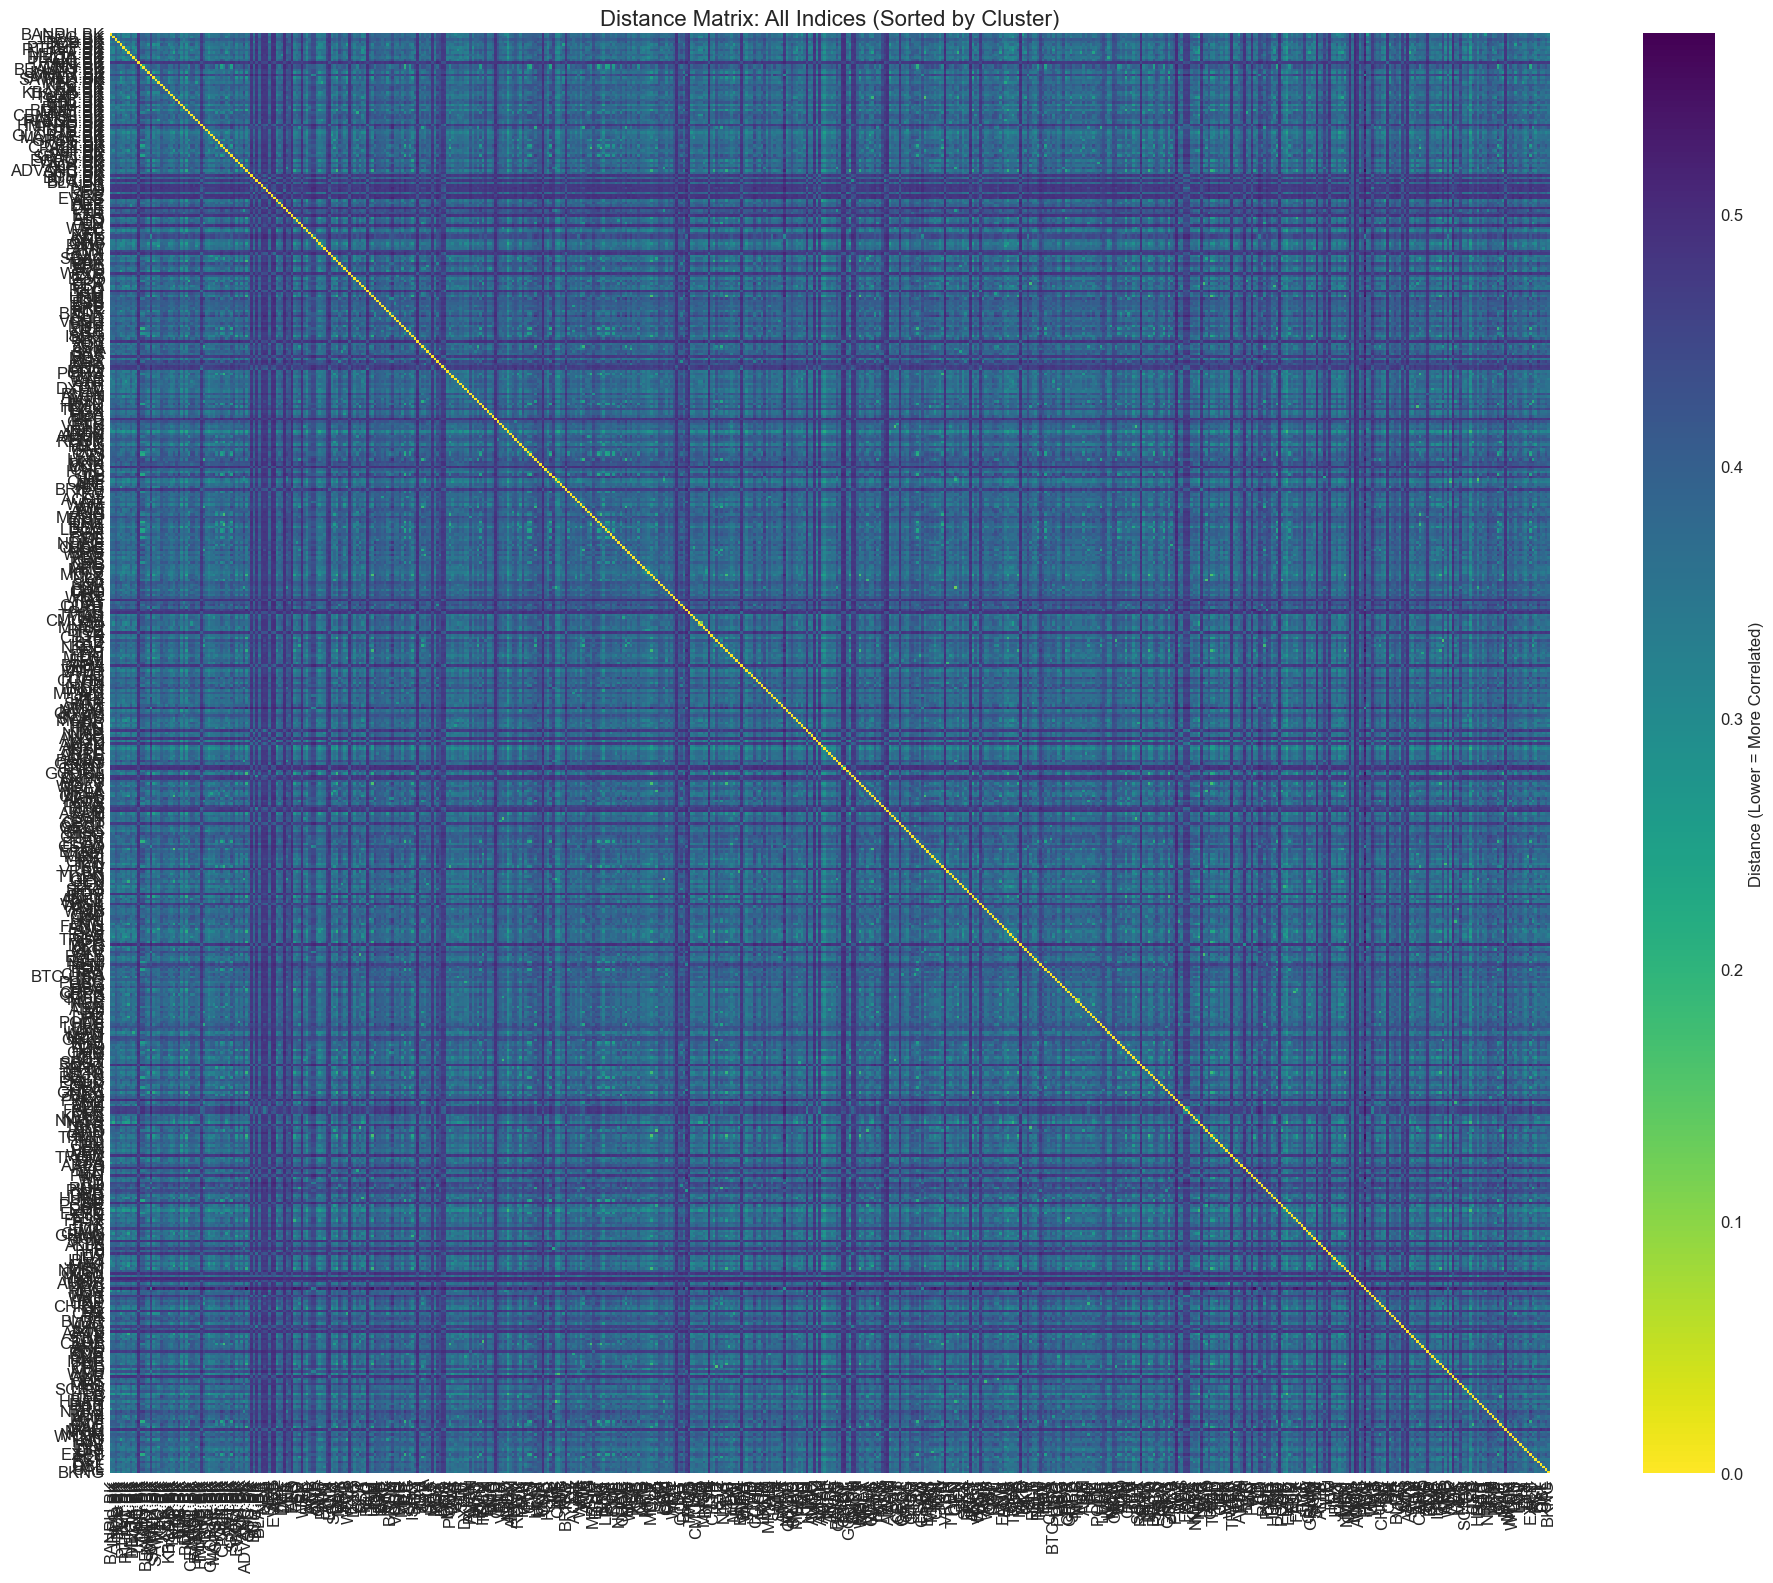

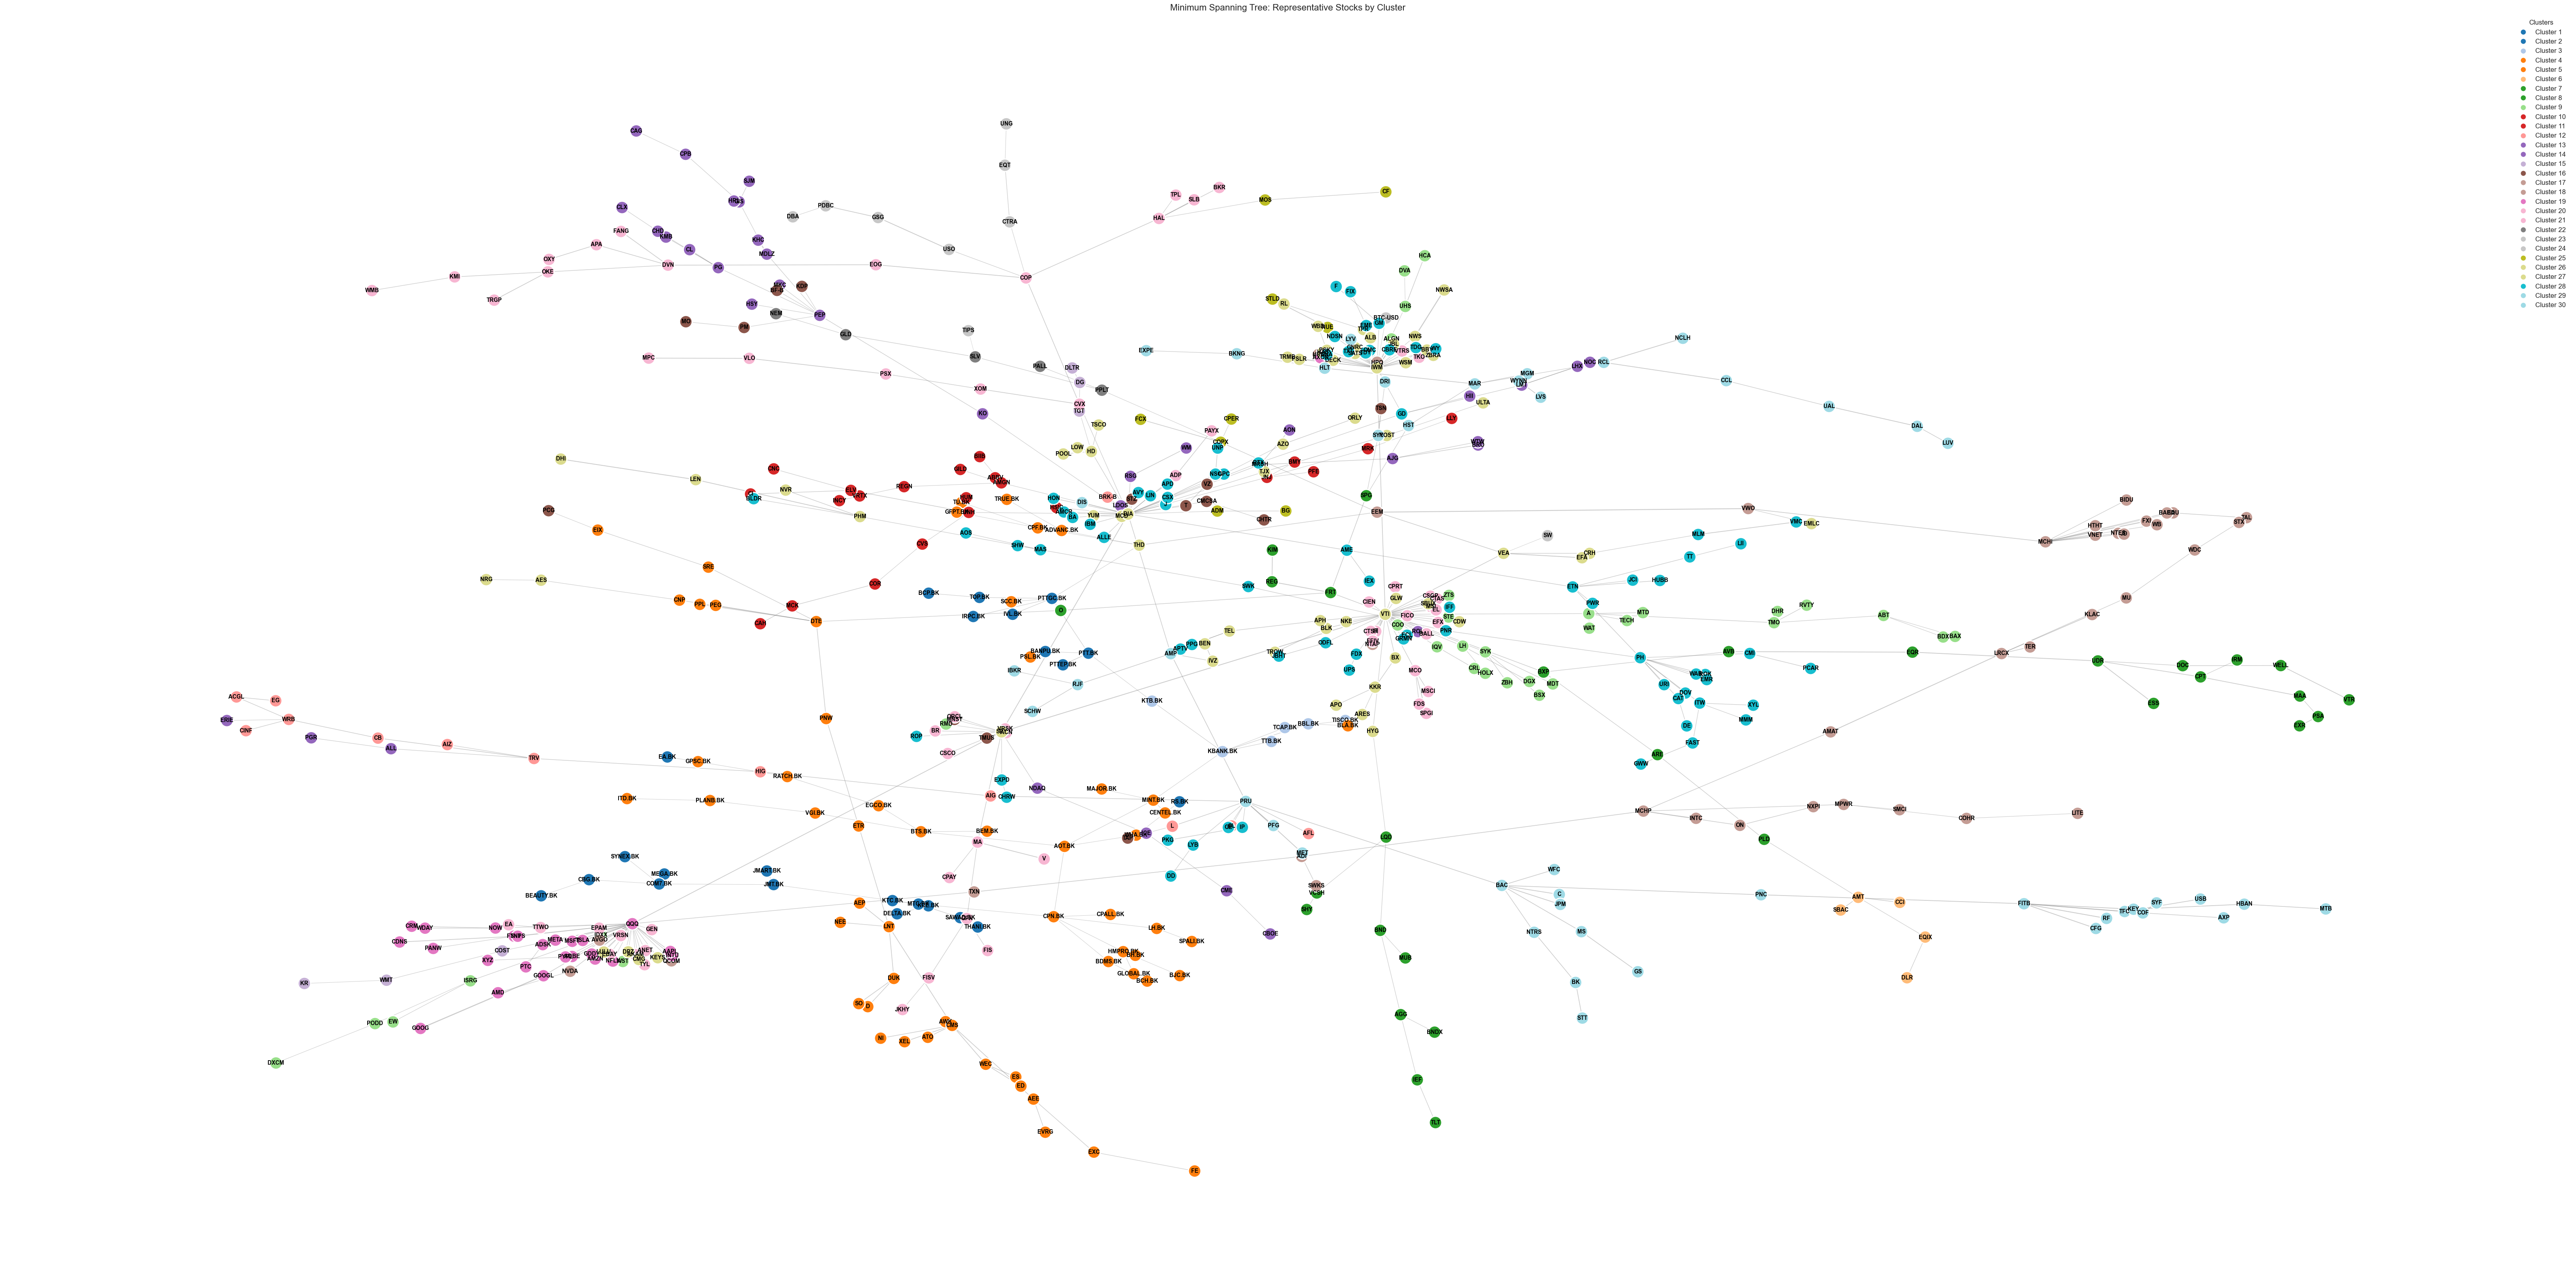

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd

# ==========================================
# 1. Heatmap of ALL Indices (Sorted by Cluster)
# ==========================================

# จัดกลุ่มหุ้นตาม Cluster เพื่อให้ Heatmap แสดงเป็นบล็อก
sorted_indices = np.argsort(cluster_labels)
sorted_tickers = [valid_tickers[i] for i in sorted_indices]
sorted_dist_matrix = distance_matrix_cpu[sorted_indices][:, sorted_indices]

plt.figure(figsize=(20, 16))

# ใช้ sns.heatmap สำหรับข้อมูลทั้งหมด 
# หมายเหตุ: ถ้าหุ้นมีจำนวนมาก (เช่น > 50 ตัว) แนะนำให้ปิด annot=False
sns.heatmap(
    distance_matrix_cpu, 
    annot=len(sorted_tickers) < 40, # แสดงตัวเลขเฉพาะถ้าหุ้นไม่เยอะเกินไป
    cmap='viridis_r', 
    xticklabels=sorted_tickers, 
    yticklabels=sorted_tickers,
    square=True,
    cbar_kws={'label': 'Distance (Lower = More Correlated)'}
)

plt.title('Distance Matrix: All Indices (Sorted by Cluster)', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 2. MST of Selected Stocks (Colorized by Cluster)
# ==========================================

# สร้าง Graph สำหรับ MST
G = nx.Graph()
n_selected = len(valid_tickers)
selected_cluster_ids = cluster_labels[sorted_indices]

for i in range(n_selected):
    for j in range(i + 1, n_selected):
        dist = distance_matrix_cpu[sorted_indices[i], sorted_indices[j]]
        G.add_edge(sorted_tickers[i], sorted_tickers[j], weight=dist)

mst = nx.minimum_spanning_tree(G)

# เตรียมสีตาม Cluster ID
unique_clusters = np.unique(selected_cluster_ids)
# ใช้ Colormap 'tab20' หรือ 'hls' สำหรับสีที่แตกต่างกันชัดเจน
colors_palette = plt.cm.get_cmap('tab20', len(unique_clusters))
cluster_to_color = {cluster: colors_palette(i) for i, cluster in enumerate(unique_clusters)}
node_colors = [cluster_to_color[cid] for cid in selected_cluster_ids]

# วาดภาพ
plt.figure(figsize=(64, 32))
pos = nx.spring_layout(mst, seed=42, )

# วาดเส้นเชื่อม (ยิ่งใกล้ เส้นยิ่งหนา)
weights = [mst[u][v]['weight'] for u, v in mst.edges()]
edge_widths = [1.0 / (w + 0.05) * 0.3 for w in weights]
nx.draw_networkx_edges(mst, pos, width=edge_widths, edge_color='gray', alpha=0.4)

# วาด Nodes
nx.draw_networkx_nodes(
    mst, pos, 
    node_size=500, 
    node_color=node_colors, 
    edgecolors='white', 
    linewidths=2
)

# วาดชื่อหุ้น
nx.draw_networkx_labels(mst, pos, font_size=10, font_weight='bold')

# สร้าง Legend สำหรับ Cluster
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Cluster {int(c)}',
           markerfacecolor=cluster_to_color[c], markersize=10)
    for c in unique_clusters
]
plt.legend(handles=legend_elements, loc='best', title="Clusters", bbox_to_anchor=(1, 1))

plt.title('Minimum Spanning Tree: Representative Stocks by Cluster', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [81]:
import numpy as np

# 1. คำนวณ Daily Simple Returns (สำหรับคำนวณ Performance Metrics จะแม่นยำกว่า Log Return ในเชิงเปรียบเทียบ)
daily_returns = np.log(data[valid_tickers] / data[valid_tickers].shift(1)).dropna()

# 2. คำนวณ Metrics รายตัว
ann_return = daily_returns.mean() * 252
ann_vol = daily_returns.std() * np.sqrt(252)
sharpe_ratio = ann_return / ann_vol

# คำนวณ Max Drawdown
cum_returns = (1 + daily_returns).cumprod()
running_max = cum_returns.cummax()
drawdown = (cum_returns - running_max) / running_max
max_drawdown = drawdown.min()

# 3. สร้าง DataFrame รวมผลลัพธ์
stats_df = pd.DataFrame({
    'Ticker': valid_tickers,
    'Cluster': cluster_labels,
    'Ann. Return (%)': ann_return.values * 100,
    'Ann. Volatility (%)': ann_vol.values * 100,
    'Sharpe Ratio': sharpe_ratio.values,
    'Max Drawdown (%)': max_drawdown.values * 100
})

# 4. แสดงผลสรุปรายกลุ่ม (Mean of each cluster)
cluster_summary = stats_df.groupby('Cluster').mean(numeric_only=True).drop(columns=['Ticker'], errors='ignore')

print("\n=== Summary Metrics by Cluster (Average) ===")
print(cluster_summary.round(2))

print("\n" + "="*85)
print(f"{'Cluster':<8} | {'Ticker':<10} | {'Return%':<10} | {'Vol%':<10} | {'Sharpe':<8} | {'MaxDD%':<10}")
print("-" * 85)

# 5. แสดงรายละเอียดหุ้นทุกตัวในแต่ละกลุ่ม
for i in range(1, num_clusters + 1):
    group = stats_df[stats_df['Cluster'] == i].sort_values(by='Sharpe Ratio' , ascending=False)
    
    for idx, row in group.iterrows():
        # ใส่เครื่องหมาย * ให้ตัวแทนกลุ่ม (Lowest Variance)
        is_rep = "*" if row['Ticker'] in selected_stocks else " "
        print(f"Group {i:<2} {is_rep} | {row['Ticker']:<10} | {row['Ann. Return (%)']:>9.2f}% | {row['Ann. Volatility (%)']:>9.2f}% | {row['Sharpe Ratio']:>8.2f} | {row['Max Drawdown (%)']:>9.2f}%")
    print("-" * 85)

print("* = Lowest Variance Representative")


=== Summary Metrics by Cluster (Average) ===
         Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Cluster                                                                      
1                   0.67                27.95          0.03            -76.07
2                   6.58                35.68          0.20            -77.52
3                   3.62                20.46          0.20            -61.40
4                   0.81                24.64          0.04            -65.85
5                   5.67                19.82          0.29            -41.55
6                   7.24                22.50          0.32            -47.54
7                   4.48                24.04          0.20            -58.13
8                   1.15                 8.10          0.16            -18.93
9                   8.50                25.32          0.34            -51.29
10                  4.85                24.12          0.22            -52.43
11                


=== สรุปผลตอบแทน ความผันผวน และเปรียบเทียบ Sharpe Ratios ===
          Annual Return (%)  Annual Vol (%)  Sharpe (Log Return)  \
Stock                                                              
NVDA              39.090302       40.680801               0.9609   
PGR               17.041700       21.210400               0.8035   
FICO              23.162001       29.356400               0.7890   
LLY               18.132099       24.273199               0.7470   
COST              14.596000       19.694599               0.7411   
CDNS              19.372000       27.383900               0.7074   
FIX               23.004900       32.741501               0.7026   
BTC-USD           39.558899       58.096500               0.6809   
ARES              19.562700       29.572201               0.6615   
TMUS              14.812200       23.086100               0.6416   
TPL               24.106001       37.839500               0.6371   
COM7.BK           19.045500       32.055500           

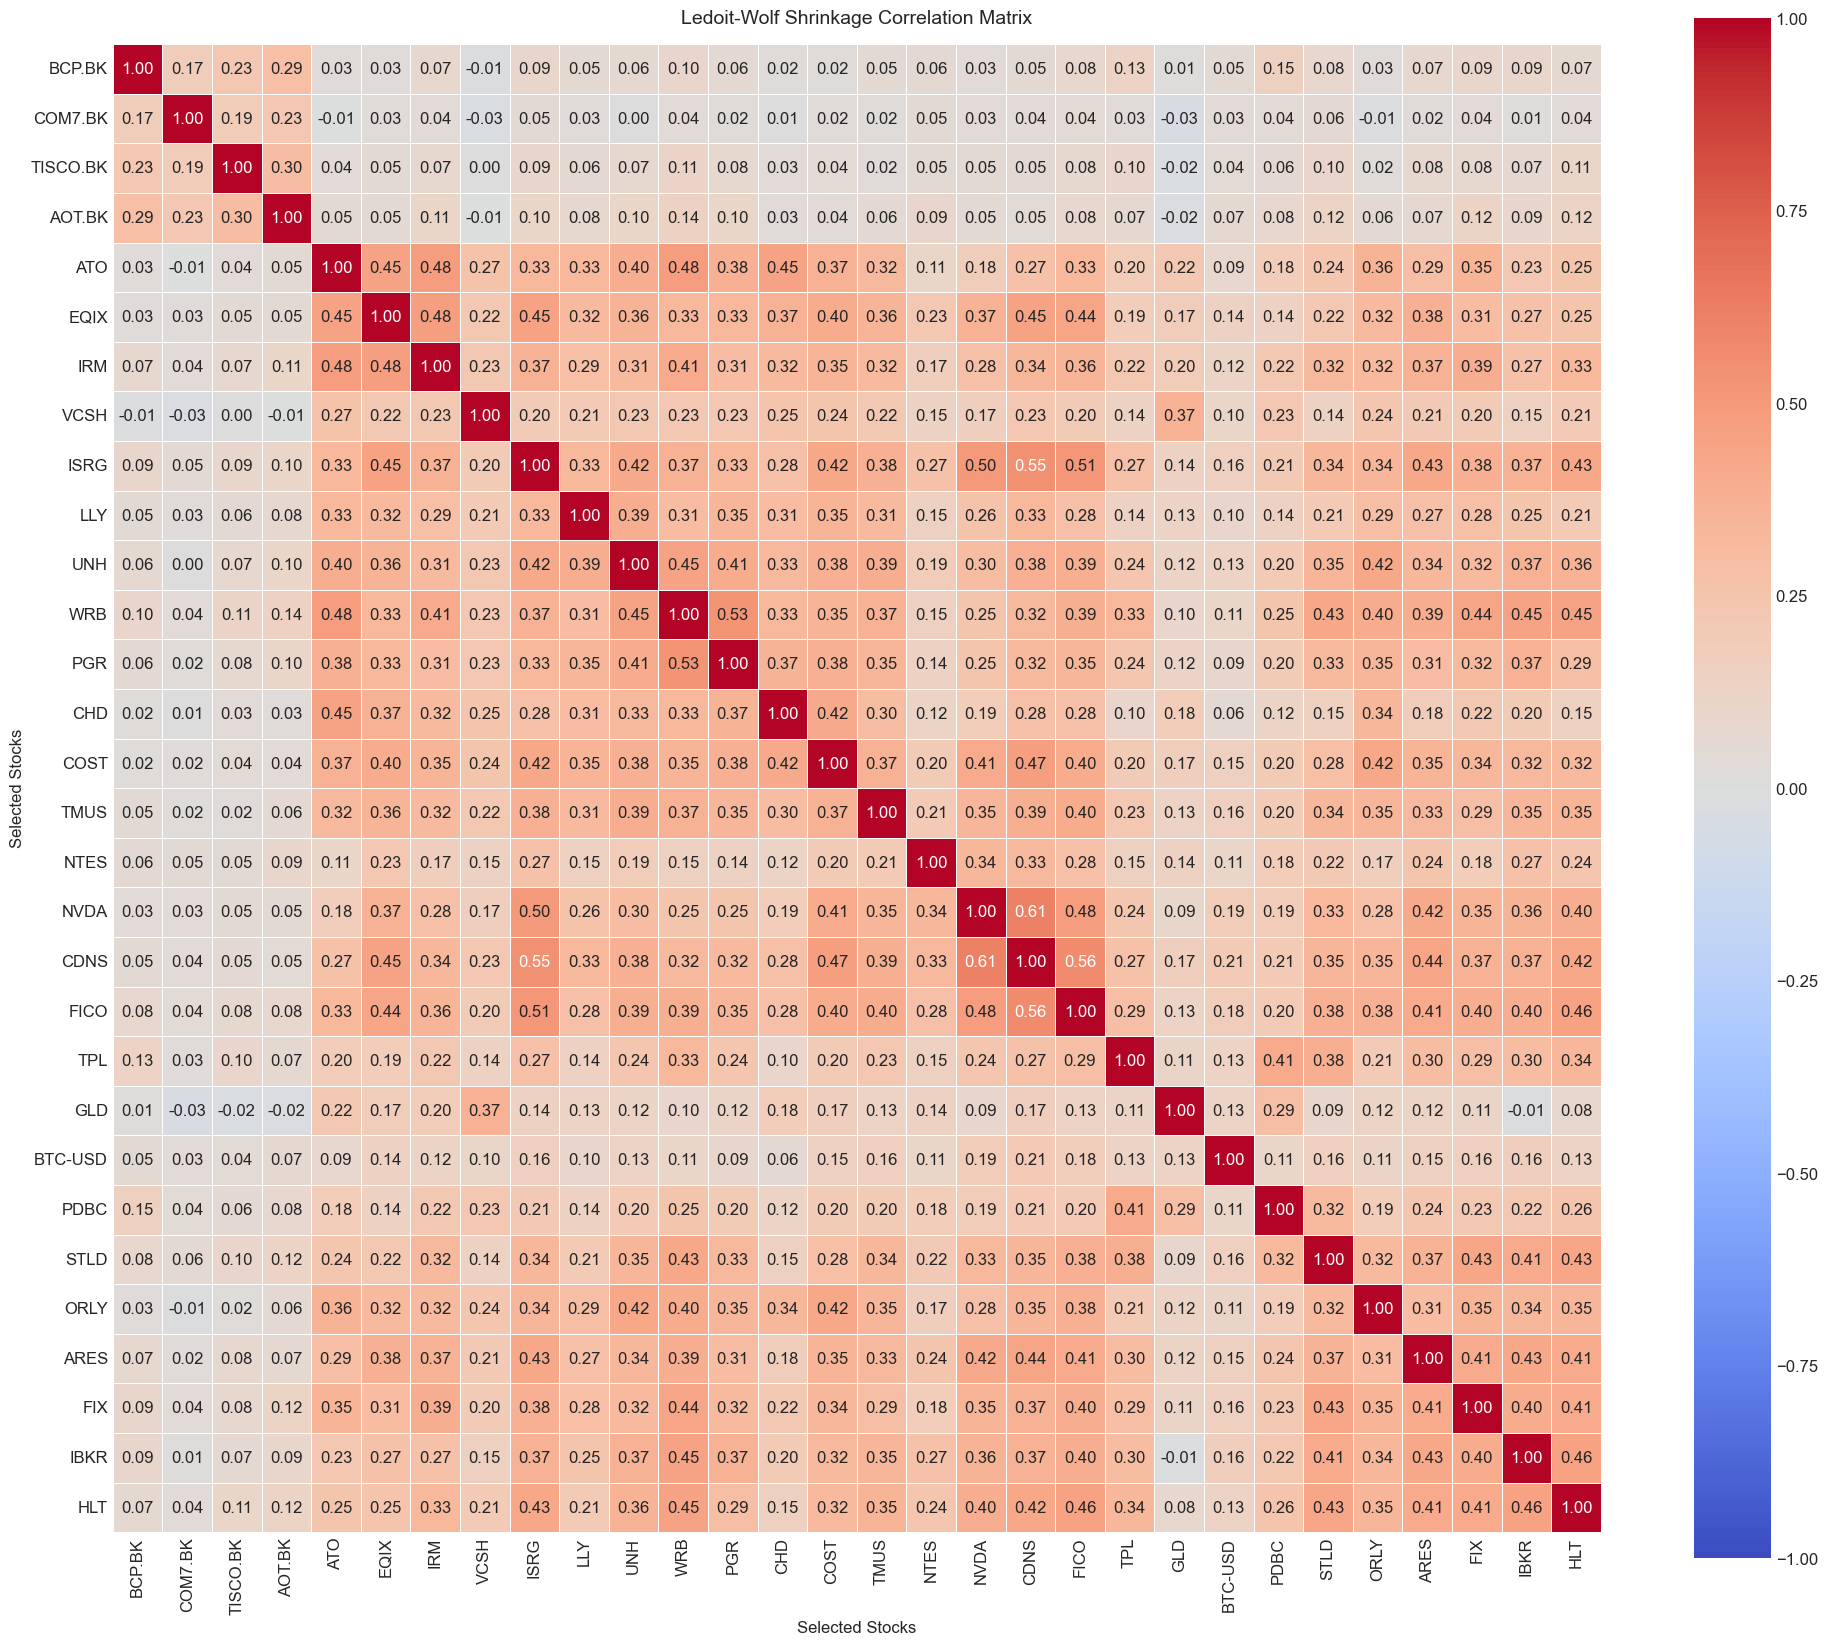

In [82]:


# หาดัชนี (Indices) ของหุ้นที่ถูกคัดเลือกจากรายชื่อหุ้นทั้งหมด
selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]

# --- 11.1 คำนวณ Sharpe Ratio แบบ Normal (Simple) Return บน GPU ---
# Normal Return = (P_t / P_{t-1}) - 1
norm_returns_gpu = (prices_tensor[1:] / prices_tensor[:-1]) - 1.0

# คำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายวันของ Normal Return บน GPU
mean_norm_returns_gpu = torch.mean(norm_returns_gpu, dim=0)
std_norm_returns_gpu = torch.std(norm_returns_gpu, dim=0, unbiased=True)

# คำนวณ Annualised Sharpe Ratio สำหรับ Normal Return
sharpe_ratios_norm_gpu = math.sqrt(252) * (mean_norm_returns_gpu / std_norm_returns_gpu)

# ย้ายผลลัพธ์ Sharpe ของ Normal Return กลับมาที่ CPU
sharpe_ratios_norm_cpu = sharpe_ratios_norm_gpu.cpu().numpy()

# --- 11.2 คำนวณ Annual Return (%) และ Annual Vol (%) จาก Log Return ---
# ใช้ mean_returns_gpu และ vols_gpu ที่คำนวณไว้แล้วในขั้นตอนที่ 10
ann_returns_cpu = mean_returns_gpu.cpu().numpy() * 252 * 100
ann_vols_cpu = vols_gpu.cpu().numpy() * math.sqrt(252) * 100

# --- 11.3 ดึงข้อมูลเฉพาะหุ้นที่ถูกคัดเลือกและสร้างตารางเปรียบเทียบ ---
selected_sharpe_log = sharpe_ratios_cpu[selected_indices]
selected_sharpe_norm = sharpe_ratios_norm_cpu[selected_indices]
selected_ann_returns = ann_returns_cpu[selected_indices]
selected_ann_vols = ann_vols_cpu[selected_indices]

# สร้างตาราง DataFrame
df_summary = pd.DataFrame({
    'Stock': selected_stocks,
    'Annual Return (%)': selected_ann_returns,
    'Annual Vol (%)': selected_ann_vols,
    'Sharpe (Log Return)': selected_sharpe_log,
    'Sharpe (Normal Return)': selected_sharpe_norm
})
df_summary.set_index('Stock', inplace=True)

# เพิ่มคอลัมน์เพื่อดูส่วนต่างของ Sharpe Ratio
df_summary['Difference (Norm - Log)'] = df_summary['Sharpe (Normal Return)'] - df_summary['Sharpe (Log Return)']

# เรียงลำดับตาม Sharpe Ratio ของ Log Return จากมากไปน้อย
df_summary = df_summary.sort_values(by='Sharpe (Log Return)', ascending=False)

print("\n=== สรุปผลตอบแทน ความผันผวน และเปรียบเทียบ Sharpe Ratios ===")
print(df_summary.round(4))

# --- 11.4 ดึง Ledoit-Wolf Shrinkage Correlation Matrix เฉพาะหุ้นที่เลือก ---
# ทำการ Slice Tensor บน GPU โดยตรง
selected_corr_tensor = corr_matrix_gpu[selected_indices][:, selected_indices]

# ย้ายผลลัพธ์กลับมาที่ CPU เพื่อใช้งานกับ Pandas
selected_corr_matrix = selected_corr_tensor.cpu().numpy()

# สร้างตาราง DataFrame สำหรับ Correlation Matrix
df_corr = pd.DataFrame(
    selected_corr_matrix, 
    index=selected_stocks, 
    columns=selected_stocks
)

print("\n=== Ledoit-Wolf Shrinkage Correlation Matrix ของกลุ่มตัวแทน ===")

import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าขนาดของกราฟ
plt.figure(figsize=(24, 20)) # ปรับขนาดกราฟให้พอดีหน้าจอมากขึ้น (24x16 อาจจะใหญ่เกินไปสำหรับบางจอ)

# สร้าง Heatmap
sns.heatmap(
    df_corr, 
    annot=True,          
    cmap='coolwarm',     
    vmin=-1.0,           
    vmax=1.0,            
    fmt=".2f",           
    linewidths=0.5,      
    square=True,         
)

# กำหนดชื่อกราฟ
plt.title('Ledoit-Wolf Shrinkage Correlation Matrix', fontsize=14, pad=15)
plt.xlabel('Selected Stocks')
plt.ylabel('Selected Stocks')

# แสดงผลกราฟ
plt.show()

In [83]:
import numpy as np

# 1. ค้นหา Index ของ Selected Stocks ใน returns_gpu
selected_indices = [list(valid_tickers).index(s) for s in selected_stocks]
selected_returns = returns_gpu[:, selected_indices]  # [days, 10]

# 2. คำนวณ Annualized Metrics (สมมติ 252 วันทำการต่อปี)
trading_days = 252
mean_returns = torch.mean(selected_returns, dim=0) * trading_days
volatilities = torch.std(selected_returns, dim=0) * np.sqrt(trading_days)
sharpe_ratios = mean_returns / volatilities  # Risk-free rate = 0

# 3. คำนวณ Max Drawdown บน GPU
# แปลง Log Return เป็น Cumulative Wealth (ราคาจำลองเริ่มต้นที่ 1)
cum_wealth = torch.exp(torch.cumsum(selected_returns, dim=0))
# หาค่าสูงสุดสะสม (Running Max)
running_max = torch.cummax(cum_wealth, dim=0).values
# คำนวณ Drawdown
drawdown = (cum_wealth / running_max) - 1
max_drawdown = torch.min(drawdown, dim=0).values

# 4. ย้ายข้อมูลกลับมาที่ CPU และทำ DataFrame
summary_df = pd.DataFrame({
    'Ticker': selected_stocks,
    'Annualized Return': mean_returns.cpu().numpy(),
    'Annualized Volatility': volatilities.cpu().numpy(),
    'Sharpe Ratio': sharpe_ratios.cpu().numpy(),
    'Max Drawdown': max_drawdown.cpu().numpy()
})

# ตกแต่งการแสดงผล
print("\n" + "="*85)
print("PERFORMANCE SUMMARY OF SELECTED REPRESENTATIVES (Low Variance per Cluster)")
print("="*85)

# Format ให้สวยงาม (ร้อยละ และ ทศนิยม 4 ตำแหน่ง)
formatted_summary = summary_df.copy()
formatted_summary['Annualized Return'] = formatted_summary['Annualized Return'].map('{:.2%}'.format)
formatted_summary['Annualized Volatility'] = formatted_summary['Annualized Volatility'].map('{:.2%}'.format)
formatted_summary['Sharpe Ratio'] = formatted_summary['Sharpe Ratio'].map('{:.4f}'.format)
formatted_summary['Max Drawdown'] = formatted_summary['Max Drawdown'].map('{:.2%}'.format)

print(formatted_summary.sort_values('Sharpe Ratio', ascending=False).to_string(index=False))
print("="*85)


PERFORMANCE SUMMARY OF SELECTED REPRESENTATIVES (Low Variance per Cluster)
  Ticker Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
    NVDA            39.09%                40.70%       0.9604      -61.87%
     PGR            17.04%                20.61%       0.8270      -22.87%
    FICO            23.16%                29.08%       0.7964      -49.29%
    COST            14.60%                19.01%       0.7679      -29.76%
     LLY            18.13%                23.81%       0.7614      -26.40%
    CDNS            19.37%                27.04%       0.7163      -32.27%
     FIX            23.00%                32.57%       0.7064      -50.37%
 BTC-USD            39.56%                58.44%       0.6769      -83.27%
    ARES            19.56%                29.30%       0.6676      -44.37%
    TMUS            14.81%                22.57%       0.6562      -31.54%
     TPL            24.11%                37.80%       0.6378      -64.25%
 COM7.BK            19.0

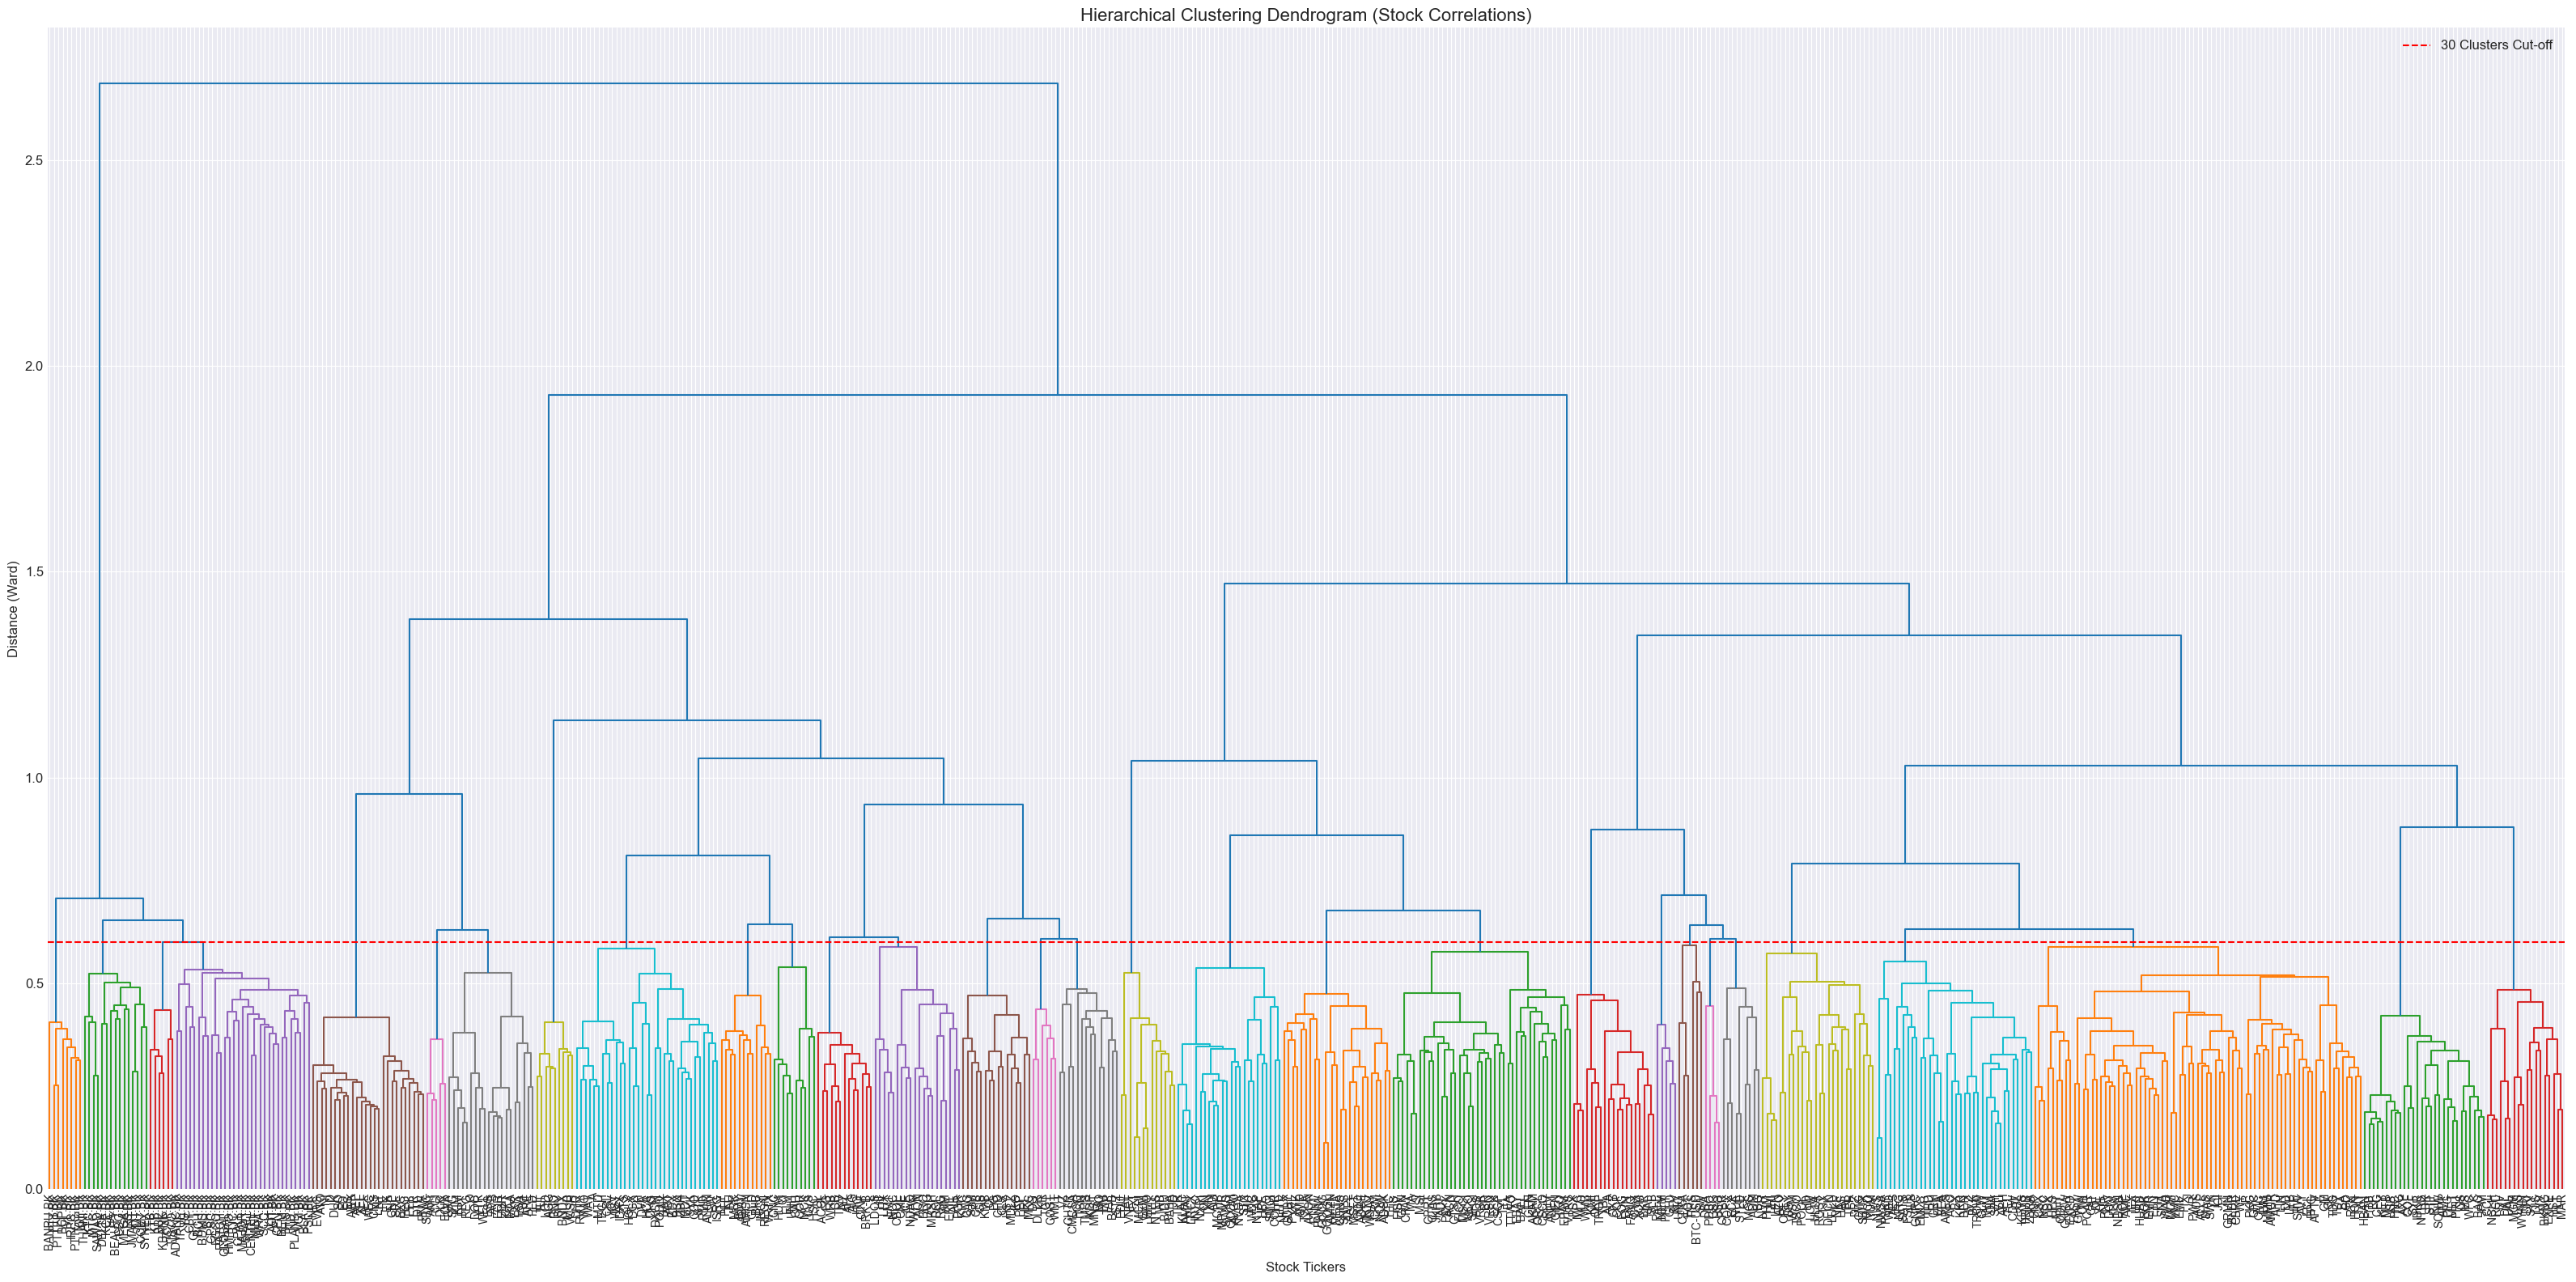

In [84]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# ตั้งค่า Font และขนาดกราฟ (รองรับภาษาไทยถ้าจำเป็น)
plt.figure(figsize=(32, 16))
plt.title("Hierarchical Clustering Dendrogram (Stock Correlations)", fontsize=16)
plt.xlabel("Stock Tickers", fontsize=12)
plt.ylabel("Distance (Ward)", fontsize=12)

# วาด Dendrogram
dendrogram(
    Z,
    labels=valid_tickers,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=Z[-(num_clusters-1), 2] # ขีดเส้นแบ่งสีตามจำนวน cluster
)

plt.axhline(y=Z[-(num_clusters-1), 2], color='r', linestyle='--', label=f'{num_clusters} Clusters Cut-off')
plt.legend()
plt.tight_layout()
plt.show()

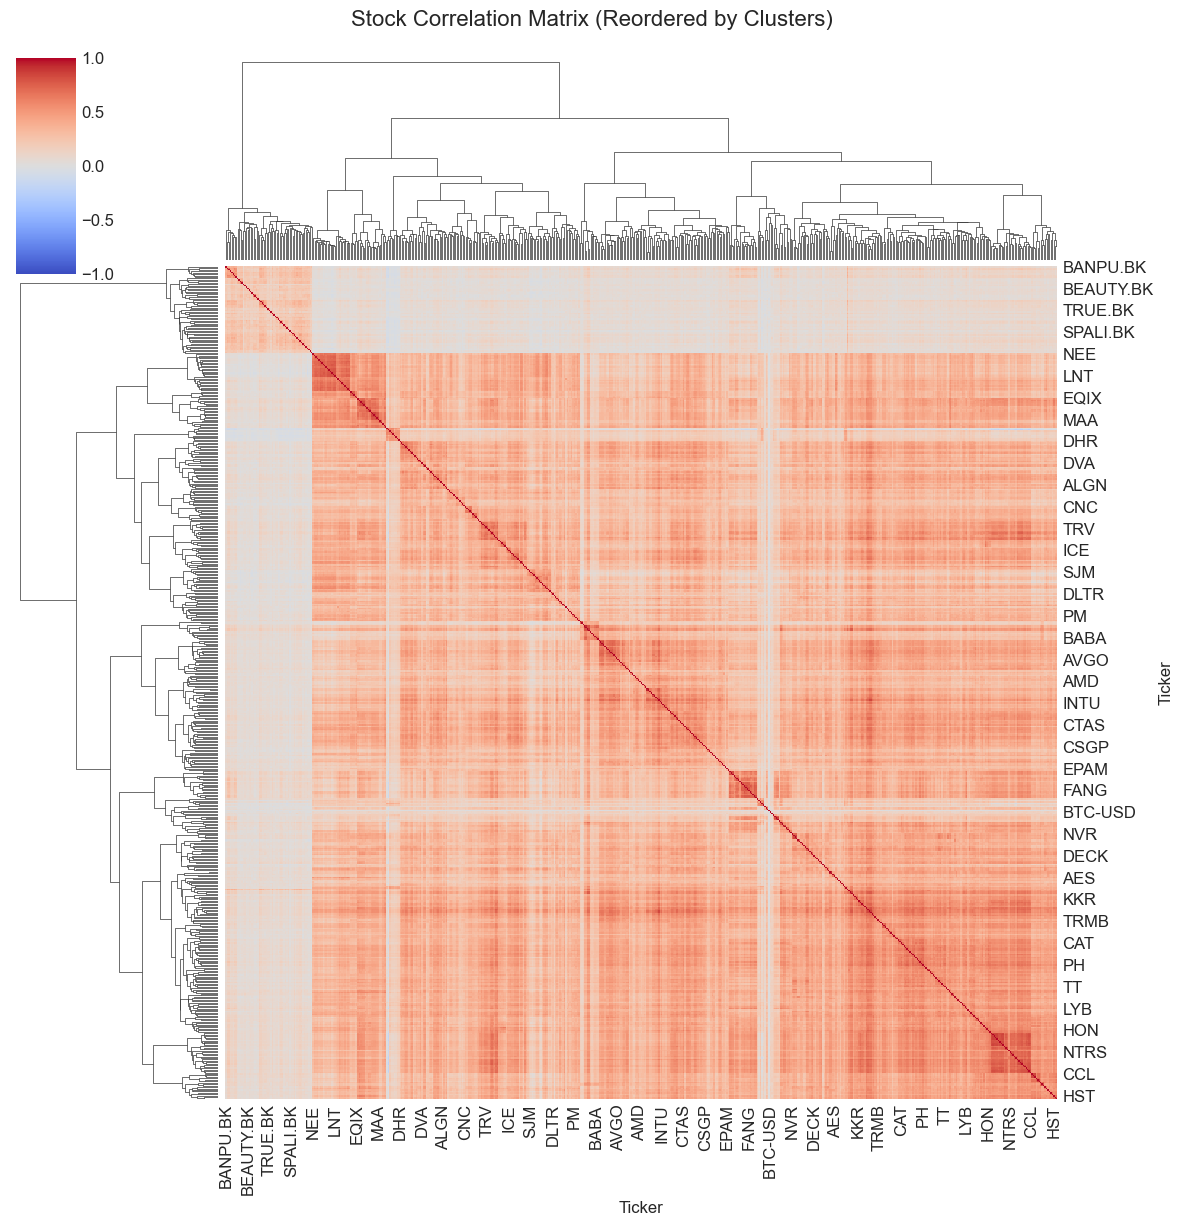

In [85]:
import seaborn as sns

# แปลง Correlation Matrix จาก GPU เป็น Numpy เพื่อวาดรูป
corr_matrix_cpu = corr_matrix_gpu.cpu().numpy()
corr_df = pd.DataFrame(corr_matrix_cpu, index=valid_tickers, columns=valid_tickers)

# ใช้ clustermap เพื่อจัดกลุ่มและแสดงสี
g = sns.clustermap(
    corr_df,
    row_linkage=Z, 
    col_linkage=Z,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    figsize=(12, 12),
    annot=False # เปลี่ยนเป็น True ถ้าหุ้นมีจำนวนน้อยและต้องการดูตัวเลข
)

g.fig.suptitle('Stock Correlation Matrix (Reordered by Clusters)', fontsize=16, y=1.02)
plt.show()


Condensed Distance Matrix Info
Shape: (163878,)
Formula: N(N-1)/2 = 573*(573-1)/2 = 163878
First 10 distance values:
[0.33893985 0.3746275  0.30979517 0.3731997  0.31321284 0.33367264
 0.31919035 0.376366   0.3311541  0.3206695 ]


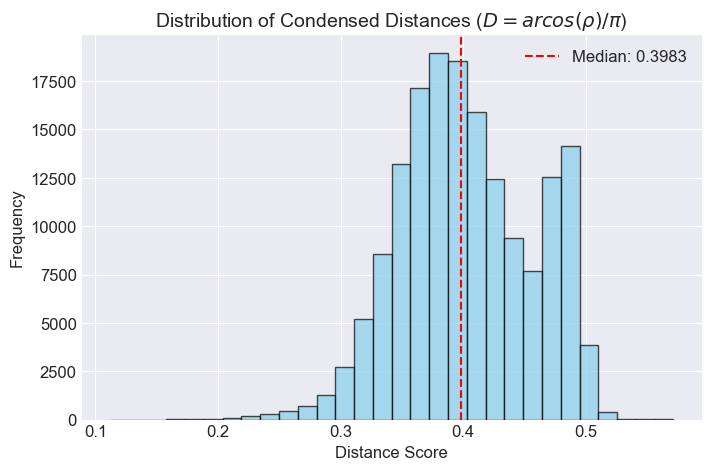

In [87]:
import numpy as np

print("\n" + "="*50)
print(f"Condensed Distance Matrix Info")
print(f"Shape: {condensed_dist.shape}")
print(f"Formula: N(N-1)/2 = {len(valid_tickers)}*({len(valid_tickers)}-1)/2 = {int(len(valid_tickers)*(len(valid_tickers)-1)/2)}")
print("="*50)

# แสดงค่า 10 ตัวแรก
print(f"First 10 distance values:\n{condensed_dist[:10]}")

# วาด Histogram ดูการกระจายตัวของ Distance
plt.figure(figsize=(8, 5))
plt.hist(condensed_dist, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.median(condensed_dist), color='red', linestyle='--', label=f'Median: {np.median(condensed_dist):.4f}')
plt.title("Distribution of Condensed Distances ($D = arcos(\\rho) /  \\pi$)", fontsize=14)
plt.xlabel("Distance Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4016. Starting rolling window process...
Rebalanced for trading period: 2017-01-27 to 2017-03-30
Rebalanced for trading period: 2017-03-31 to 2017-06-01
Rebalanced for trading period: 2017-06-02 to 2017-08-03
Rebalanced for trading period: 2017-08-04 to 2017-10-05
Rebalanced for trading period: 2017-10-06 to 2017-12-07
Rebalanced for trading period: 2017-12-08 to 2018-02-08
Rebalanced for trading period: 2018-02-09 to 2018-04-12
Rebalanced for trading period: 2018-04-13 to 2018-06-14
Rebalanced for trading period: 2018-06-15 to 2018-08-16
Rebalanced for trading period: 2018-08-17 to 2018-10-18
Rebalanced for trading period: 2018-10-19 to 2018-12-20
Rebalanced for trading period: 2018-12-21 to 2019-02-21
Rebalanced for trading period: 2019-02-22 to 2019-04-25
Rebalanced for trading period: 2019-04-26 to 2019-06-27
Rebalanced for trading period: 2019-06-28 to 2019-08-29
Rebalanced for trading period: 2019-08-30 to 2019-10-31
Rebalanced for trading period: 2019-11-01 t

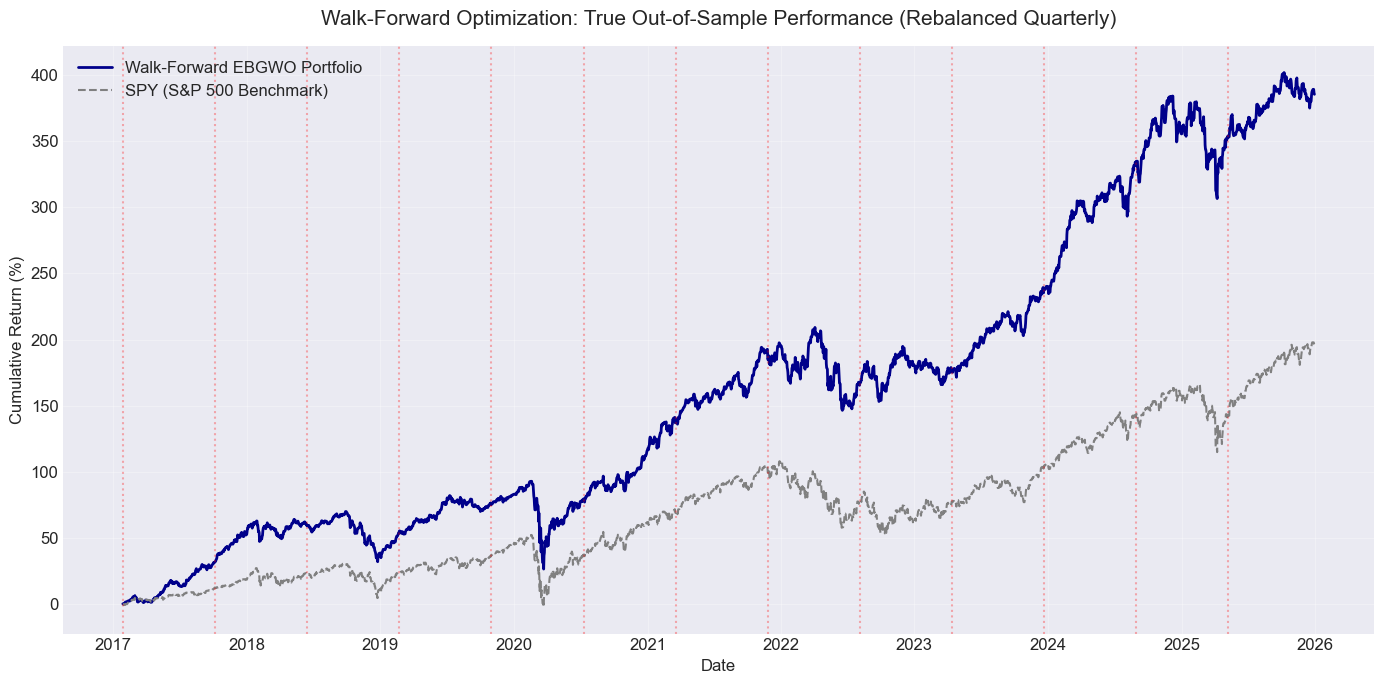


=== Walk-Forward Performance Metrics ===
Annualized Return:      13.15%
Annualized Volatility:  13.66%
Sharpe Ratio:           0.9632

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 385.47%               | 196.39%
Annualized Return      | 13.15%               | 9.60%
Annualized Volatility  | 13.66%               | 15.42%
Sharpe Ratio           | 0.9632                | 0.6222
Max Drawdown           | -34.45%               | -35.75%
--------------------------------------------------------------------


In [99]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]
def calculate_fitness_er_ga(wolves, returns_gpu, lambda_ent=0.1, risk_free_rate=0.0434):
    """
    คำนวณ Fitness ด้วย Entropy-Regularised Sharpe Ratio
    """
    n_assets = wolves.shape[1]
    sqrt_252 = math.sqrt(252)
    eps = 1e-10 # ป้องกัน log(0)
    
    # 1. คำนวณ Sharpe Ratio
    portfolio_returns = torch.matmul(returns_gpu, wolves.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    sharpe_ratios = torch.where(port_ann_vol > 0, (port_ann_return - risk_free_rate) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. คำนวณ Normalised Entropy: H(w) / log(n)
    # entropy = -sum(w * log(w))
    entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
    norm_entropy = entropy / math.log(n_assets)
    
    # 3. รวม Objective
    fitness = sharpe_ratios + (lambda_ent * norm_entropy)
    return fitness

def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.8, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    Objective: Maximize [Sharpe Ratio + lambda_ent * Normalized_Entropy]
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    log_n = math.log(num_assets)
    ST = 0.2
    eps = 1e-10  # ป้องกัน log(0)
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # 1. คำนวณ Portfolio Performance
        portfolio_returns = torch.matmul(mc_returns, wolves.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sharpe Ratio
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # 3. [NEW] คำนวณ Normalised Entropy (H(w) / log(n))
        # Formula: -sum(w * log(w))
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # 4. คำนวณ Penalty (จำกัด max_weight)
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS = Sharpe + (lambda * Entropy) - Penalty
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 5. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 6. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        # Vectorized Update for X1, X2, X3
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global



print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start=start_date, end="2025-12-31")['Close']
max_gap = 365

# Find columns that have a gap of NaNs larger than max_gap
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()

# Filter them out
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()
# full_returns =  full_data.pct_change().dropna()
# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    # ใน Loop Walk-Forward
    best_weights = optimize_weights_ebgwo_monte_carlo_entropy(
        train_returns, 
        max_weight=0.08, 
        lambda_ent=0.00,  # ปรับเพิ่มถ้าอยากให้พอร์ตกระจายหุ้นมากขึ้น
        num_wolves=100, 
        iterations=300
    )
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 6.57%               | 16.44%
Annualized Return      | 5.13%               | 11.81%
Annualized Volatility  | 12.05%               | 15.98%
Sharpe Ratio           | 0.4263                | 0.7391
Max Drawdown           | -15.26%               | -19.21%
--------------------------------------------------------------------


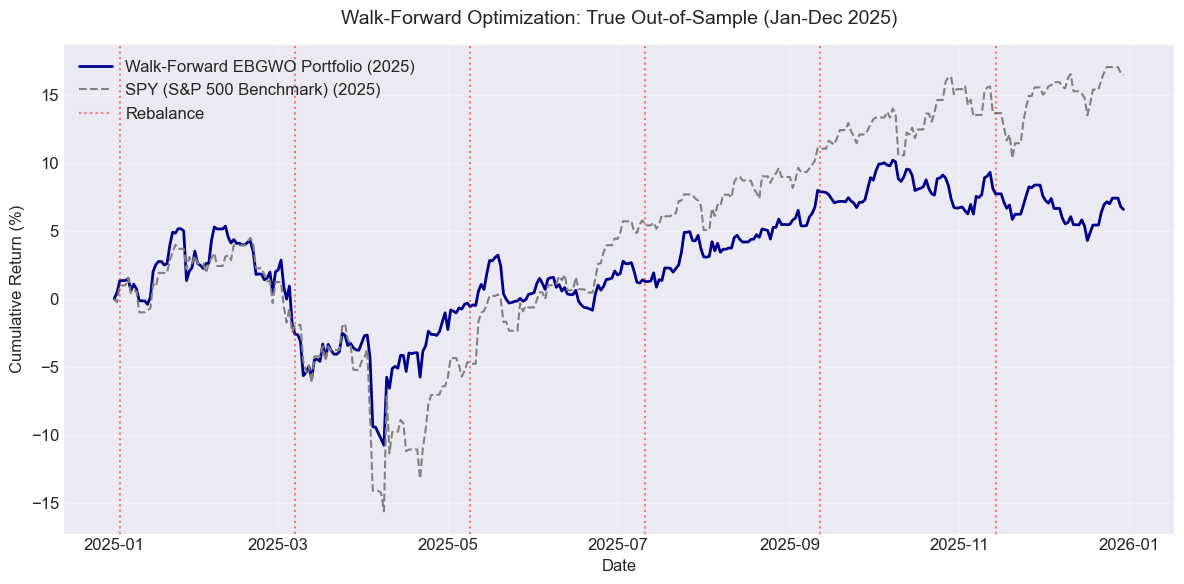

In [100]:
# --- กรองข้อมูลและประมวลผลเฉพาะปี 2025 ---

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

# ดึงวันที่และผลตอบแทนรายวันเฉพาะปี 2025
dates_2025 = trade_dates[mask_2025]
port_returns_2025 = np.array(out_of_sample_port_returns)[mask_2025]
spy_returns_2025 = np.array(out_of_sample_spy_returns)[mask_2025]

# 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ในวันที่ 1 ม.ค. 2025)
cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1

wf_cum_return_2025 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
spy_cum_return_2025 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0

# 2. Annualized Return สำหรับปี 2025
wf_ann_return_2025 = np.mean(port_returns_2025) * 252
spy_ann_return_2025 = np.mean(spy_returns_2025) * 252

# 3. Annualized Volatility สำหรับปี 2025
wf_ann_vol_2025 = np.std(port_returns_2025) * math.sqrt(252)
spy_ann_vol_2025 = np.std(spy_returns_2025) * math.sqrt(252)

# 4. Sharpe Ratio สำหรับปี 2025
wf_sharpe_2025 = wf_ann_return_2025 / wf_ann_vol_2025 if wf_ann_vol_2025 > 0 else 0
spy_sharpe_2025 = spy_ann_return_2025 / spy_ann_vol_2025 if spy_ann_vol_2025 > 0 else 0

# 5. Max Drawdown ภายในปี 2025
rolling_max_port_2025 = np.maximum.accumulate(1 + cum_port_2025)
drawdown_port_2025 = (1 + cum_port_2025) / rolling_max_port_2025 - 1
wf_max_dd_2025 = np.min(drawdown_port_2025) if len(drawdown_port_2025) > 0 else 0

rolling_max_spy_2025 = np.maximum.accumulate(1 + cum_spy_2025)
drawdown_spy_2025 = (1 + cum_spy_2025) / rolling_max_spy_2025 - 1
spy_max_dd_2025 = np.min(drawdown_spy_2025) if len(drawdown_spy_2025) > 0 else 0

# --- แสดงผลตารางแบบฟอร์แมต (เฉพาะปี 2025) ---
print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return_2025:.2%} {'':<13} | {spy_cum_return_2025:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return_2025:.2%} {'':<13} | {spy_ann_return_2025:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol_2025:.2%} {'':<13} | {spy_ann_vol_2025:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe_2025:.4f} {'':<14} | {spy_sharpe_2025:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd_2025:.2%} {'':<13} | {spy_max_dd_2025:.2%}")
print("-" * 68)

# --- พล็อตกราฟเฉพาะปี 2025 ---
plt.figure(figsize=(12, 6))
plt.plot(dates_2025, cum_port_2025 * 100, label='Walk-Forward EBGWO Portfolio (2025)', color='darkblue', linewidth=2)
plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark) (2025)', color='gray', linestyle='--', linewidth=1.5)

# กรอง Rebalance dates เฉพาะที่อยู่ในปี 2025 มาแสดงเป็นเส้นประ
rebalance_2025 = [date for date in rebalance_dates if date.startswith('2025')]
for date in rebalance_2025:
    plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.5, label='Rebalance' if date == rebalance_2025[0] else "")

plt.title('Walk-Forward Optimization: True Out-of-Sample (Jan-Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 1. จัดเตรียมข้อมูลน้ำหนักของแต่ละช่วงเวลา (Weight History) ---
# สร้าง DataFrame เพื่อเก็บประวัติน้ำหนักหุ้น
# df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)

# # กรองเฉพาะช่วงปี 2025
# df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# # --- 2. แสดงตารางน้ำหนักล่าสุด (Latest Weights in 2025) ---
# latest_weights = df_weight_2025.iloc[-1]
# latest_weights_df = pd.DataFrame({
#     'Ticker': latest_weights.index,
#     'Weight': latest_weights.values
# }).sort_values(by='Weight', ascending=False)

# print("\n=== Final Asset Weights (Latest Rebalance in 2025) ===")
# print(latest_weights_df.to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

# # --- 3. พล็อตกราฟการเปลี่ยนแปลงน้ำหนัก (Asset Weights Evolution) ---
# plt.figure(figsize=(14, 7))
# # ใช้ Stacked Area Chart เพื่อดูสัดส่วนรวมเป็น 100%
# plt.stackplot(pd.to_datetime(df_weight_2025.index), 
#               df_weight_2025.T, 
#               labels=df_weight_2025.columns,
#               alpha=0.8)

# plt.title('Asset Weights Evolution (Walk-Forward 2025)', fontsize=14, pad=15)
# plt.xlabel('Rebalance Date')
# plt.ylabel('Portfolio Allocation (%)')
# # ปรับ Legend ให้อยู่ด้านนอกถ้าหุ้นเยอะ
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize='small')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()


=== Asset Weights (Latest Rebalance in 2025) ===
  Ticker Weight
    NVDA  8.00%
     GLD  7.91%
    IBKR  7.73%
     WRB  7.58%
     FIX  7.35%
    ORLY  7.17%
TISCO.BK  7.15%
     ATO  6.56%
    TMUS  6.26%
    NTES  5.70%
     PGR  5.70%
    COST  5.06%
    ISRG  4.87%
 COM7.BK  3.38%
     LLY  2.87%
     CHD  2.75%
    FICO  2.50%
 BTC-USD  0.53%
     UNH  0.38%
    ARES  0.32%
     TPL  0.08%
    CDNS  0.06%
  BCP.BK  0.03%
    VCSH  0.03%
     IRM  0.02%
    EQIX  0.01%
     HLT  0.00%
    STLD  0.00%
  AOT.BK  0.00%
    PDBC  0.00%


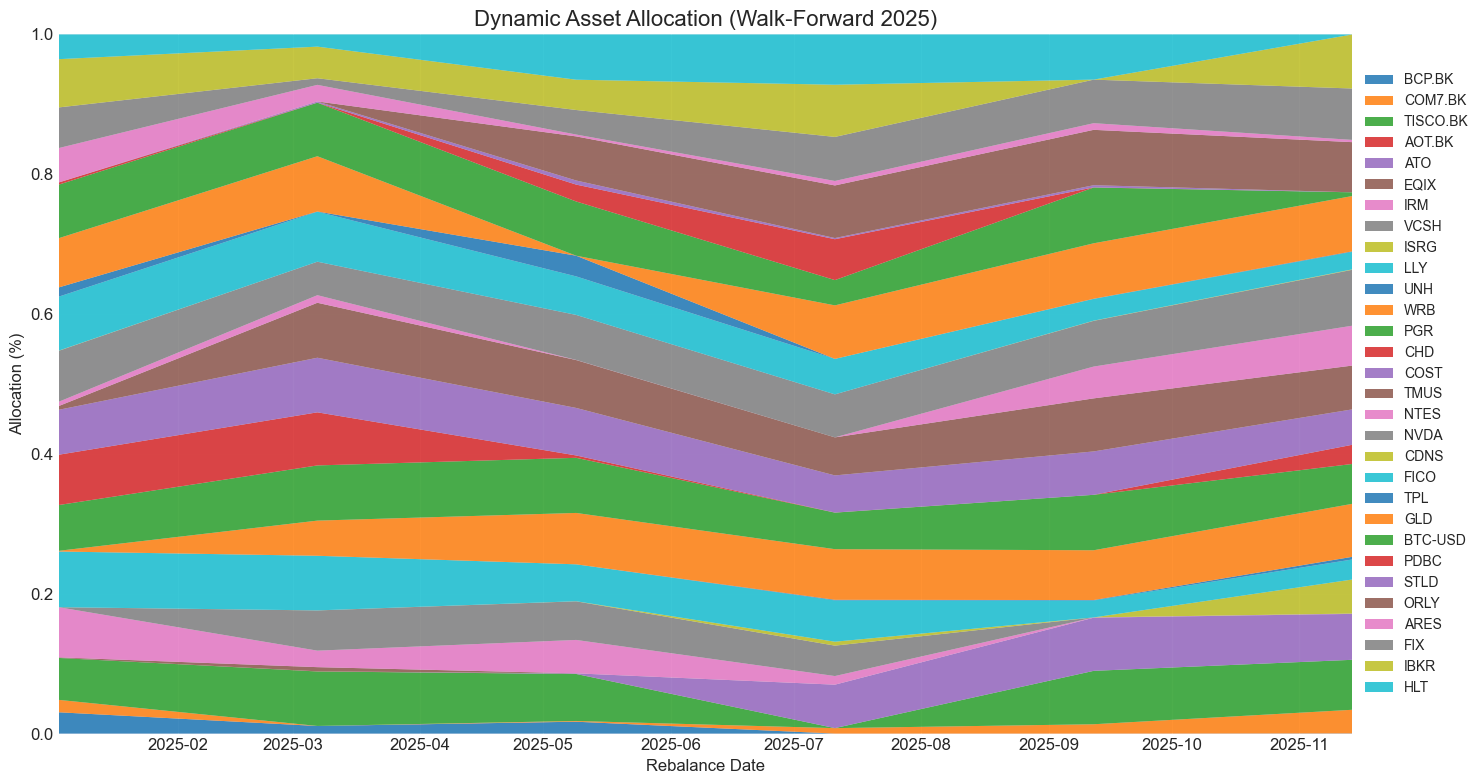

In [101]:
# --- 1. จัดเตรียมข้อมูลน้ำหนักปี 2025 ---
df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)
df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# --- 2. ตารางน้ำหนักล่าสุด (ปลายปี 2025) ---
if not df_weight_2025.empty:
    latest_weights = df_weight_2025.iloc[-1]
    latest_weights_df = pd.DataFrame({
        'Ticker': latest_weights.index,
        'Weight': latest_weights.values
    }).sort_values(by='Weight', ascending=False)

    print("\n=== Asset Weights (Latest Rebalance in 2025) ===")
    # แสดงเฉพาะตัวที่มีน้ำหนักมากกว่า 0.1% เพื่อความชัดเจน
    print(latest_weights_df[latest_weights_df['Weight'] > 0.0].to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

    # --- 3. กราฟ Stacked Area Chart (Weights Evolution) ---
    plt.figure(figsize=(15, 8))
    # กรองเฉพาะหุ้นที่มีน้ำหนักเฉลี่ยในปี 2025 เกิน 1% มาแสดงใน Legend (เพื่อไม่ให้ Legend บังรูป)
    important_stocks = df_weight_2025.columns[df_weight_2025.mean() > 0.0]
    
    plt.stackplot(pd.to_datetime(df_weight_2025.index), 
                  df_weight_2025.T, 
                  labels=df_weight_2025.columns,
                  alpha=0.85)

    plt.title('Dynamic Asset Allocation (Walk-Forward 2025)', fontsize=16)
    plt.ylabel('Allocation (%)')
    plt.xlabel('Rebalance Date')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=1)
    plt.grid(axis='y', alpha=0.2)
    plt.margins(0,0)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for year 2025 in the weight history.")

[                       0%                       ]


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4016. Starting rolling window process...
Rebalanced for trading period: 2017-01-27 to 2017-03-30
Rebalanced for trading period: 2017-03-31 to 2017-06-01
Rebalanced for trading period: 2017-06-02 to 2017-08-03
Rebalanced for trading period: 2017-08-04 to 2017-10-05
Rebalanced for trading period: 2017-10-06 to 2017-12-07
Rebalanced for trading period: 2017-12-08 to 2018-02-08
Rebalanced for trading period: 2018-02-09 to 2018-04-12
Rebalanced for trading period: 2018-04-13 to 2018-06-14
Rebalanced for trading period: 2018-06-15 to 2018-08-16
Rebalanced for trading period: 2018-08-17 to 2018-10-18
Rebalanced for trading period: 2018-10-19 to 2018-12-20
Rebalanced for trading period: 2018-12-21 to 2019-02-21
Rebalanced for trading period: 2019-02-22 to 2019-04-25
Rebalanced for trading period: 2019-04-26 to 2019-06-27
Rebalanced for trading period: 2019-06-28 to 2019-08-29
Rebalanced for trading period: 2019-08-30 to 2019-10-31
Rebalanced for trading period: 2019-11-01 t

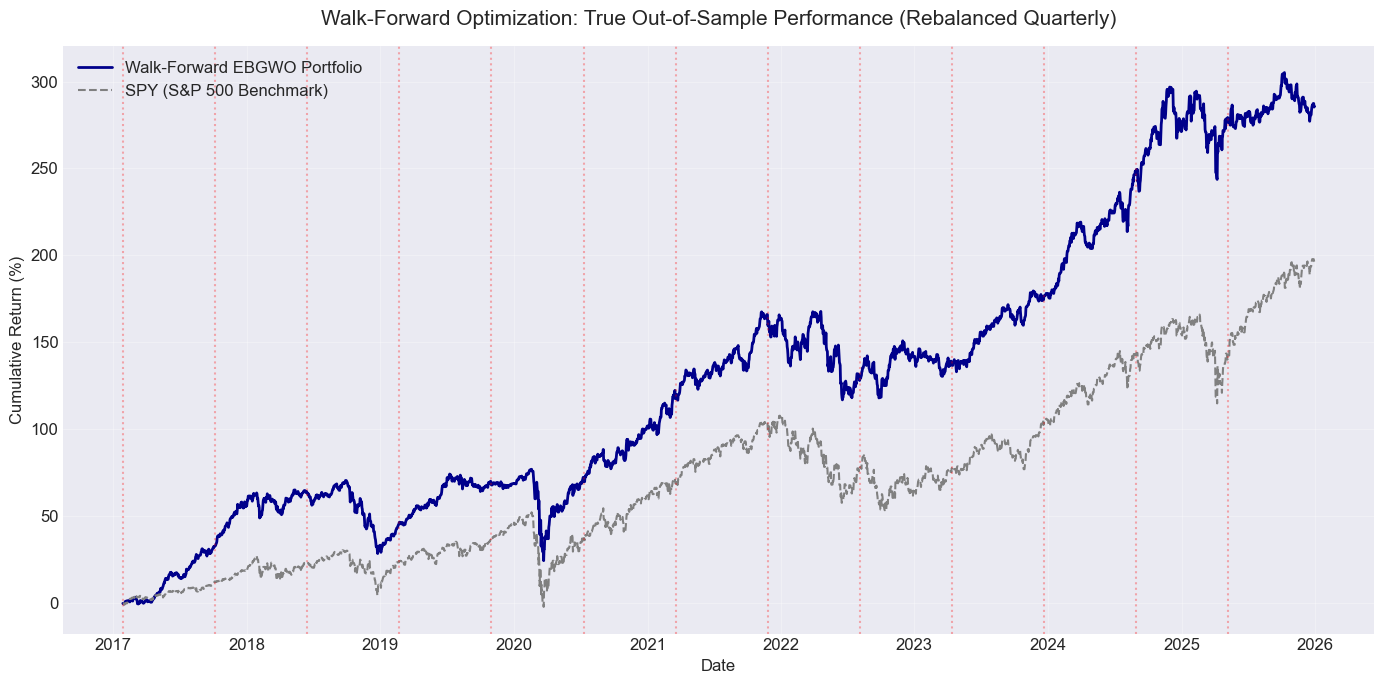


=== Walk-Forward Performance Metrics ===
Annualized Return:      11.25%
Annualized Volatility:  12.73%
Sharpe Ratio:           0.8837

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 285.65%               | 196.39%
Annualized Return      | 11.25%               | 9.60%
Annualized Volatility  | 12.73%               | 15.42%
Sharpe Ratio           | 0.8837                | 0.6222
Max Drawdown           | -29.72%               | -35.75%
--------------------------------------------------------------------


In [106]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]
def calculate_fitness_er_ga(wolves, returns_gpu, lambda_ent=0.1, risk_free_rate=0.0434):
    """
    คำนวณ Fitness ด้วย Entropy-Regularised Sharpe Ratio
    """
    n_assets = wolves.shape[1]
    sqrt_252 = math.sqrt(252)
    eps = 1e-10 # ป้องกัน log(0)
    
    # 1. คำนวณ Sharpe Ratio
    portfolio_returns = torch.matmul(returns_gpu, wolves.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    sharpe_ratios = torch.where(port_ann_vol > 0, (port_ann_return - risk_free_rate) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. คำนวณ Normalised Entropy: H(w) / log(n)
    # entropy = -sum(w * log(w))
    entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
    norm_entropy = entropy / math.log(n_assets)
    
    # 3. รวม Objective
    fitness = sharpe_ratios + (lambda_ent * norm_entropy)
    return fitness

def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.8, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    Objective: Maximize [Sharpe Ratio + lambda_ent * Normalized_Entropy]
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    log_n = math.log(num_assets)
    ST = 0.2
    eps = 1e-10  # ป้องกัน log(0)
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # 1. คำนวณ Portfolio Performance
        portfolio_returns = torch.matmul(mc_returns, wolves.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sharpe Ratio
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # 3. [NEW] คำนวณ Normalised Entropy (H(w) / log(n))
        # Formula: -sum(w * log(w))
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # 4. คำนวณ Penalty (จำกัด max_weight)
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS = Sharpe + (lambda * Entropy) - Penalty
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 5. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 6. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        # Vectorized Update for X1, X2, X3
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

def optimize_weights_aco_2d_monte_carlo(train_returns_gpu, max_weight=0.8, lambda_ent=0.05, num_ants=100, num_bins=100, iterations=300):
    """
    Ant Colony Optimization Using 2D Pheromone Matrix (Assets x Weight Bins)
    Objective: Maximize [Sharpe Ratio + lambda_ent * Normalized_Entropy]
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    log_n = math.log(num_assets)
    eps = 1e-10  # ป้องกัน log(0)
    
    # ---------------------------------------------------------
    # ตั้งค่าตัวแปร ACO (2D Pheromones)
    # ---------------------------------------------------------
    rho = 0.1       # Evaporation Rate (อัตราการระเหย)
    Q = 1.0         # Pheromone deposit factor
    num_elite = max(1, int(num_ants * 0.1)) # คัดเลือกเฉพาะ Top 10% มาวางฟีโรโมน
    
    # สร้าง Weight Bins จาก 0 ถึง max_weight
    weight_bins = torch.linspace(0.0, max_weight, num_bins, device=device)
    
    # เมทริกซ์ฟีโรโมน 2 มิติ: ขนาด (จำนวนสินทรัพย์, จำนวนระดับน้ำหนัก)
    pheromones = torch.ones((num_assets, num_bins), dtype=torch.float32, device=device)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # 1. แปลงความเข้มข้นฟีโรโมนให้เป็นค่าความน่าจะเป็น (Probabilities)
        probs = pheromones / pheromones.sum(dim=1, keepdim=True)
        
        # 2. ให้มดทุกตัวสุ่มเลือกระดับน้ำหนักสำหรับแต่ละหุ้นพร้อมกัน (Vectorized)
        # multinomial จะคืนค่า index ของ bins ขนาด (num_assets, num_ants)
        selected_indices = torch.multinomial(probs, num_samples=num_ants, replacement=True)
        
        # Transpose เพื่อให้มิติเป็น (num_ants, num_assets)
        selected_indices = selected_indices.T
        
        # แปลง Index เป็นค่าน้ำหนักดิบ (Raw Weights)
        raw_weights = weight_bins[selected_indices]
        
        # 3. Normalize ให้ผลรวมของแต่ละพอร์ตโฟลิโอ (มดแต่ละตัว) เท่ากับ 1
        sums = raw_weights.sum(dim=1, keepdim=True)
        ants_weights = torch.where(sums > 0, raw_weights / sums, torch.ones_like(raw_weights)/num_assets)
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # 1. คำนวณ Portfolio Performance
        portfolio_returns = torch.matmul(mc_returns, ants_weights.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sharpe Ratio
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # 3. คำนวณ Normalised Entropy: H(w) / log(n)
        entropy = -torch.sum(ants_weights * torch.log(ants_weights + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # 4. คำนวณ Penalty สำหรับขีดจำกัดน้ำหนัก (เผื่อในกรณี Normalize แล้วมีค่าหลุดเกิน max_weight)
        weight_penalties = torch.sum(torch.relu(ants_weights - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS = Sharpe + (lambda * Entropy) - Penalty
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # อัปเดต Global Best
        max_fitness, max_idx = torch.max(fitnesses, dim=0)
        if max_fitness.item() > best_fitness_global:
            best_fitness_global = max_fitness.item()
            best_weights_global = ants_weights[max_idx].clone().cpu().numpy()
            
        # ========================================================
        # PHEROMONE UPDATE (เฉพาะกลุ่ม Elite)
        # ========================================================
        # จัดเรียงเพื่อหา Top Ants
        sorted_indices_fit = torch.argsort(fitnesses, descending=True)
        
        # ระเหยฟีโรโมน (Evaporation)
        pheromones = pheromones * (1.0 - rho)
        
        # เติมฟีโรโมน (Deposit) เฉพาะตัวที่ทำผลงานได้ดี
        for rank in range(num_elite):
            ant_idx = sorted_indices_fit[rank]
            ant_bins_chosen = selected_indices[ant_idx] # index ของระดับน้ำหนักที่มดตัวนั้นเลือก
            
            # การวางฟีโรโมนแปรผันตามอันดับ (Rank-based Pheromone)
            deposit_amount = Q / (rank + 1)
            
            # อัปเดตเมทริกซ์ฟีโรโมนแบบพิกัด (Vectorized Pheromone Deposit)
            pheromones[torch.arange(num_assets, device=device), ant_bins_chosen] += deposit_amount
            
        # ควบคุมขอบเขตฟีโรโมน (Max-Min Ant System concept) ป้องกันการลู่เข้าหากลุ่มเดิมไวเกินไป
        pheromones = torch.clamp(pheromones, min=1e-4, max=10.0)

    return best_weights_global


print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start=start_date, end="2025-12-31")['Close']
max_gap = 365

# Find columns that have a gap of NaNs larger than max_gap
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()

# Filter them out
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()
# full_returns =  full_data.pct_change().dropna()
# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    


    best_weights = optimize_weights_aco_2d_monte_carlo(
        train_returns, 
        max_weight=0.08, 
        lambda_ent=0.00,  
        num_ants=200,     # จำนวนมด (ยิ่งมากยิ่งค้นหาได้กว้าง แต่ใช้เวลามากขึ้น)
        num_bins=100,     # ความละเอียดของน้ำหนักที่มดจะเลือกได้
        iterations=300
    )
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 3.90%               | 16.44%
Annualized Return      | 3.34%               | 11.81%
Annualized Volatility  | 11.77%               | 15.98%
Sharpe Ratio           | 0.2840                | 0.7391
Max Drawdown           | -12.88%               | -19.21%
--------------------------------------------------------------------


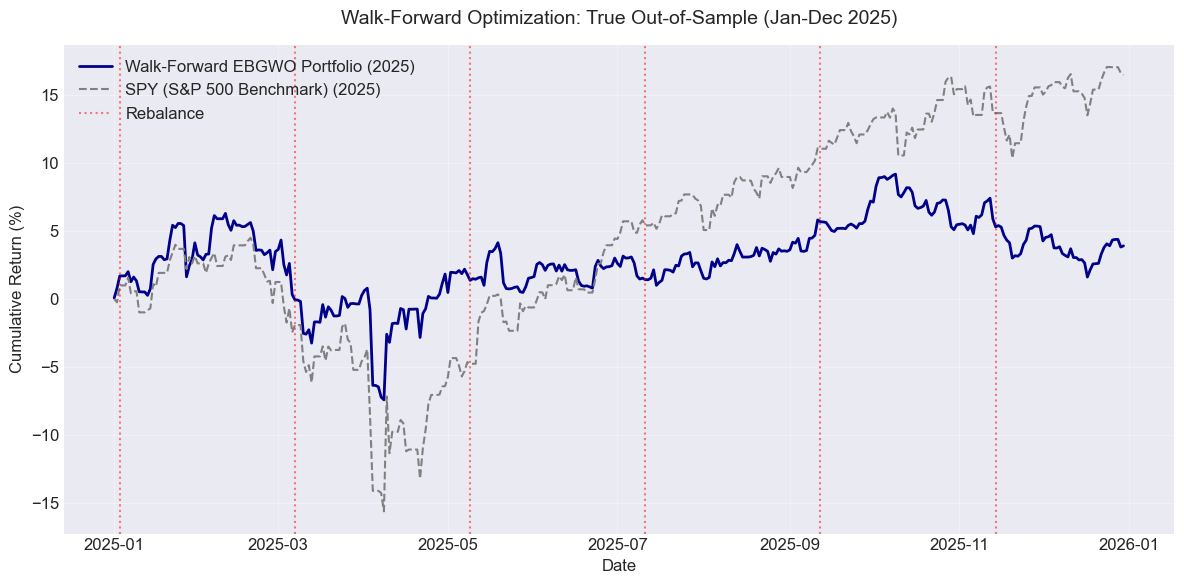

In [ ]:
# --- กรองข้อมูลและประมวลผลเฉพาะปี 2025 ---

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

# ดึงวันที่และผลตอบแทนรายวันเฉพาะปี 2025
dates_2025 = trade_dates[mask_2025]
port_returns_2025 = np.array(out_of_sample_port_returns)[mask_2025]
spy_returns_2025 = np.array(out_of_sample_spy_returns)[mask_2025]

# 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ในวันที่ 1 ม.ค. 2025)
cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1

wf_cum_return_2025 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
spy_cum_return_2025 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0

# 2. Annualized Return สำหรับปี 2025
wf_ann_return_2025 = np.mean(port_returns_2025) * 252
spy_ann_return_2025 = np.mean(spy_returns_2025) * 252

# 3. Annualized Volatility สำหรับปี 2025
wf_ann_vol_2025 = np.std(port_returns_2025) * math.sqrt(252)
spy_ann_vol_2025 = np.std(spy_returns_2025) * math.sqrt(252)

# 4. Sharpe Ratio สำหรับปี 2025
wf_sharpe_2025 = wf_ann_return_2025 / wf_ann_vol_2025 if wf_ann_vol_2025 > 0 else 0
spy_sharpe_2025 = spy_ann_return_2025 / spy_ann_vol_2025 if spy_ann_vol_2025 > 0 else 0

# 5. Max Drawdown ภายในปี 2025
rolling_max_port_2025 = np.maximum.accumulate(1 + cum_port_2025)
drawdown_port_2025 = (1 + cum_port_2025) / rolling_max_port_2025 - 1
wf_max_dd_2025 = np.min(drawdown_port_2025) if len(drawdown_port_2025) > 0 else 0

rolling_max_spy_2025 = np.maximum.accumulate(1 + cum_spy_2025)
drawdown_spy_2025 = (1 + cum_spy_2025) / rolling_max_spy_2025 - 1
spy_max_dd_2025 = np.min(drawdown_spy_2025) if len(drawdown_spy_2025) > 0 else 0

# --- แสดงผลตารางแบบฟอร์แมต (เฉพาะปี 2025) ---
print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return_2025:.2%} {'':<13} | {spy_cum_return_2025:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return_2025:.2%} {'':<13} | {spy_ann_return_2025:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol_2025:.2%} {'':<13} | {spy_ann_vol_2025:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe_2025:.4f} {'':<14} | {spy_sharpe_2025:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd_2025:.2%} {'':<13} | {spy_max_dd_2025:.2%}")
print("-" * 68)

# --- พล็อตกราฟเฉพาะปี 2025 ---
plt.figure(figsize=(12, 6))
plt.plot(dates_2025, cum_port_2025 * 100, label='Walk-Forward EBGWO Portfolio (2025)', color='darkblue', linewidth=2)
plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark) (2025)', color='gray', linestyle='--', linewidth=1.5)

# กรอง Rebalance dates เฉพาะที่อยู่ในปี 2025 มาแสดงเป็นเส้นประ
rebalance_2025 = [date for date in rebalance_dates if date.startswith('2025')]
for date in rebalance_2025:
    plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.5, label='Rebalance' if date == rebalance_2025[0] else "")

plt.title('Walk-Forward Optimization: True Out-of-Sample (Jan-Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Using device: cuda

=== Walk-Forward Performance Metrics (2022-2025 Backtest) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 46.43%               | 43.41%
Annualized Return      | 7.26%               | 7.33%
Annualized Volatility  | 11.63%               | 14.89%
Sharpe Ratio           | 0.6242                | 0.4922
Max Drawdown           | -19.00%               | -26.22%
--------------------------------------------------------------------


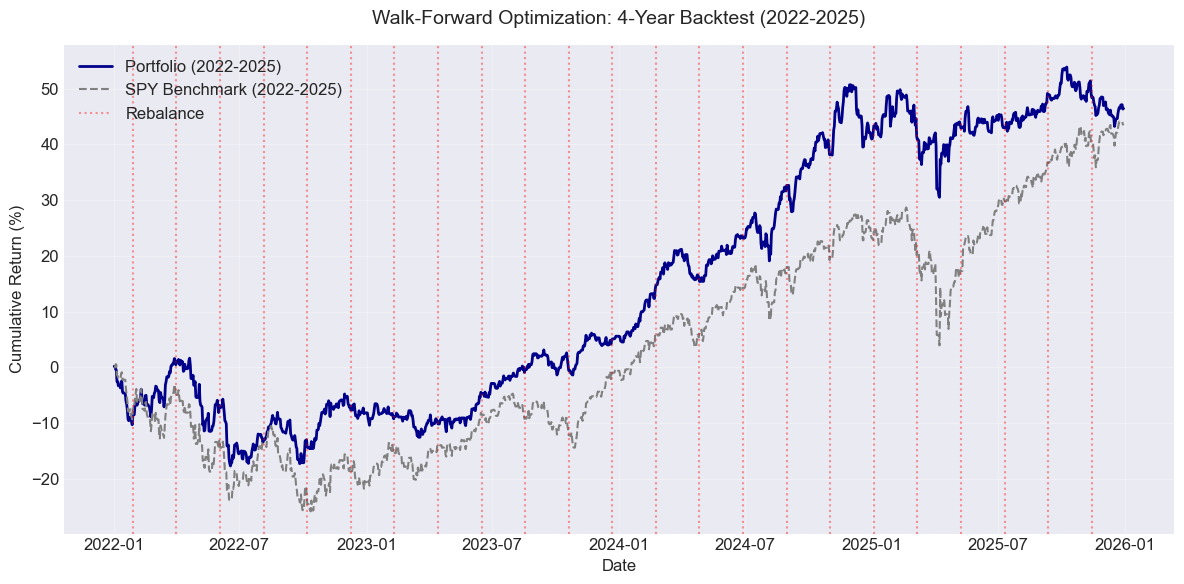

In [109]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ตรวจสอบการใช้งาน GPU ตามที่คุณต้องการ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 1. กรองข้อมูลสำหรับ Backtest 4 ปี (เช่น 2022 - 2025) ---

# กำหนดช่วงปี (4 ปีล่าสุด)
start_year = 2022
end_year = 2025
mask_4yr = (trade_dates.year >= start_year) & (trade_dates.year <= end_year)

# ดึงวันที่และเตรียมข้อมูล Returns
dates_4yr = trade_dates[mask_4yr]

# แปลงข้อมูลเป็น PyTorch Tensor และย้ายไปยัง GPU
port_returns_tensor = torch.tensor(np.array(out_of_sample_port_returns)[mask_4yr], dtype=torch.float32).to(device)
spy_returns_tensor = torch.tensor(np.array(out_of_sample_spy_returns)[mask_4yr], dtype=torch.float32).to(device)

# --- 2. คำนวณ Performance Metrics ด้วย PyTorch ---

# Cumulative Return: (cumprod(1 + r) - 1)
cum_port_4yr = torch.cumprod(1 + port_returns_tensor, dim=0) - 1
cum_spy_4yr = torch.cumprod(1 + spy_returns_tensor, dim=0) - 1

wf_cum_return_val = cum_port_4yr[-1].item() if len(cum_port_4yr) > 0 else 0
spy_cum_return_val = cum_spy_4yr[-1].item() if len(cum_spy_4yr) > 0 else 0

# Annualized Return: (Mean Return * 252)
wf_ann_return_val = torch.mean(port_returns_tensor).item() * 252
spy_ann_return_val = torch.mean(spy_returns_tensor).item() * 252

# Annualized Volatility: (Std * sqrt(252))
wf_ann_vol_val = torch.std(port_returns_tensor).item() * math.sqrt(252)
spy_ann_vol_val = torch.std(spy_returns_tensor).item() * math.sqrt(252)

# Sharpe Ratio
wf_sharpe_val = wf_ann_return_val / wf_ann_vol_val if wf_ann_vol_val > 0 else 0
spy_sharpe_val = spy_ann_return_val / spy_ann_vol_val if spy_ann_vol_val > 0 else 0

# Max Drawdown (คำนวณโดยใช้ torch.cummax)
def get_max_drawdown_torch(cum_returns_tensor):
    if len(cum_returns_tensor) == 0: return 0
    wealth_index = 1 + cum_returns_tensor
    running_max, _ = torch.cummax(wealth_index, dim=0)
    drawdowns = (wealth_index / running_max) - 1
    return torch.min(drawdowns).item()

wf_max_dd_val = get_max_drawdown_torch(cum_port_4yr)
spy_max_dd_val = get_max_drawdown_torch(cum_spy_4yr)

# --- 3. แสดงผลตาราง (4-Year Backtest) ---

print(f"\n=== Walk-Forward Performance Metrics ({start_year}-{end_year} Backtest) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return_val:.2%} {'':<13} | {spy_cum_return_val:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return_val:.2%} {'':<13} | {spy_ann_return_val:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol_val:.2%} {'':<13} | {spy_ann_vol_val:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe_val:.4f} {'':<14} | {spy_sharpe_val:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd_val:.2%} {'':<13} | {spy_max_dd_val:.2%}")
print("-" * 68)

# --- 4. พล็อตกราฟ (ดึงข้อมูลกลับมาที่ CPU สำหรับ Matplotlib) ---

plt.figure(figsize=(12, 6))
plt.plot(dates_4yr, cum_port_4yr.cpu().numpy() * 100, label=f'Portfolio ({start_year}-{end_year})', color='darkblue', linewidth=2)
plt.plot(dates_4yr, cum_spy_4yr.cpu().numpy() * 100, label=f'SPY Benchmark ({start_year}-{end_year})', color='gray', linestyle='--', linewidth=1.5)

# กรอง Rebalance dates เฉพาะที่อยู่ในช่วง 4 ปี
rebalance_in_range = [d for d in rebalance_dates if start_year <= pd.to_datetime(d).year <= end_year]
for i, date in enumerate(rebalance_in_range):
    plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.4, label='Rebalance' if i == 0 else "")

plt.title(f'Walk-Forward Optimization: 4-Year Backtest ({start_year}-{end_year})', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== Asset Weights (Latest Rebalance in 2025) ===
  Ticker Weight
     GLD  7.81%
     ATO  7.73%
    TMUS  7.65%
TISCO.BK  7.57%
     WRB  7.57%
    COST  7.41%
 BTC-USD  7.09%
     PGR  6.93%
    NVDA  6.85%
     FIX  6.77%
    VCSH  6.14%
    ORLY  5.74%
    IBKR  5.34%
    NTES  4.54%
     HLT  1.59%
    FICO  1.04%
  BCP.BK  0.48%
  AOT.BK  0.32%
    ISRG  0.32%
     LLY  0.24%
    EQIX  0.16%
     TPL  0.16%
    ARES  0.16%
    STLD  0.16%
     IRM  0.08%
 COM7.BK  0.08%
    CDNS  0.08%


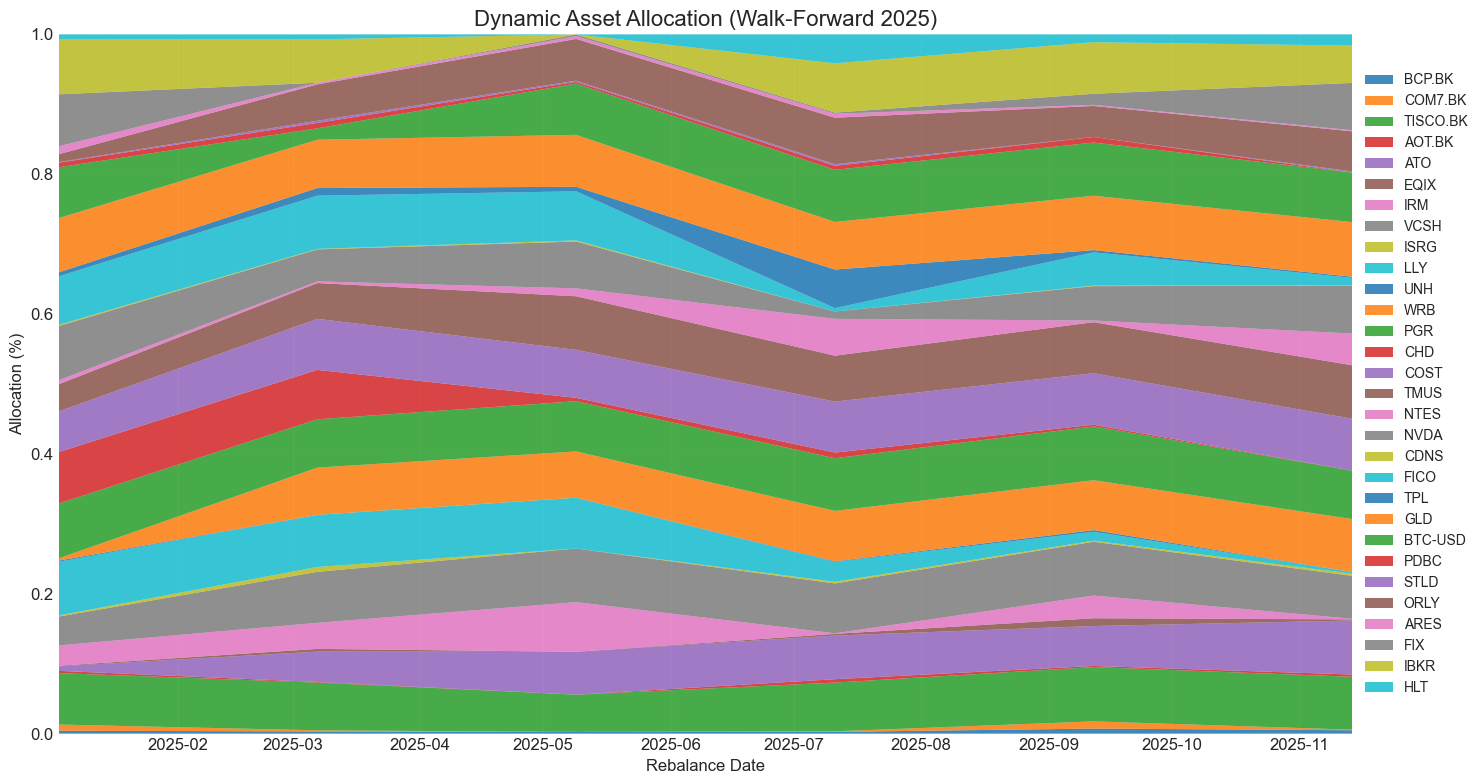

In [108]:
# --- 1. จัดเตรียมข้อมูลน้ำหนักปี 2025 ---
df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)
df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# --- 2. ตารางน้ำหนักล่าสุด (ปลายปี 2025) ---
if not df_weight_2025.empty:
    latest_weights = df_weight_2025.iloc[-1]
    latest_weights_df = pd.DataFrame({
        'Ticker': latest_weights.index,
        'Weight': latest_weights.values
    }).sort_values(by='Weight', ascending=False)

    print("\n=== Asset Weights (Latest Rebalance in 2025) ===")
    # แสดงเฉพาะตัวที่มีน้ำหนักมากกว่า 0.1% เพื่อความชัดเจน
    print(latest_weights_df[latest_weights_df['Weight'] > 0.0].to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

    # --- 3. กราฟ Stacked Area Chart (Weights Evolution) ---
    plt.figure(figsize=(15, 8))
    # กรองเฉพาะหุ้นที่มีน้ำหนักเฉลี่ยในปี 2025 เกิน 1% มาแสดงใน Legend (เพื่อไม่ให้ Legend บังรูป)
    important_stocks = df_weight_2025.columns[df_weight_2025.mean() > 0.0]
    
    plt.stackplot(pd.to_datetime(df_weight_2025.index), 
                  df_weight_2025.T, 
                  labels=df_weight_2025.columns,
                  alpha=0.85)

    plt.title('Dynamic Asset Allocation (Walk-Forward 2025)', fontsize=16)
    plt.ylabel('Allocation (%)')
    plt.xlabel('Rebalance Date')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=1)
    plt.grid(axis='y', alpha=0.2)
    plt.margins(0,0)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for year 2025 in the weight history.")